Noise: 78.0
CSV guardado en: csv_generats/simulated_clusters_CM_1.csv
CSV guardado en: csv_generats/simulated_clusters_CM_2.csv
CSV guardado en: csv_generats/simulated_clusters_CM_3.csv
CSV guardado en: csv_generats/simulated_clusters_CM_4.csv
CSV guardado en: csv_generats/simulated_clusters_CM_5.csv
CSV guardado en: csv_generats/simulated_clusters_CM_6.csv
CSV guardado en: csv_generats/simulated_clusters_CM_7.csv
CSV guardado en: csv_generats/simulated_clusters_CM_8.csv
CSV guardado en: csv_generats/simulated_clusters_CM_9.csv
CSV guardado en: csv_generats/simulated_clusters_CM_10.csv
CSV guardado en: csv_generats/simulated_clusters_CM_11.csv
CSV guardado en: csv_generats/simulated_clusters_CM_12.csv
CSV guardado en: csv_generats/simulated_clusters_CM_13.csv
CSV guardado en: csv_generats/simulated_clusters_CM_14.csv
CSV guardado en: csv_generats/simulated_clusters_CM_15.csv
CSV guardado en: csv_generats/simulated_clusters_CM_16.csv
CSV guardado en: csv_generats/simulated_clusters_CM_1

/var/folders/rf/xh_185_x0sl5vv3vjbwyt0r40000gn/T/ipykernel_241/3469698424.py:87: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(10, 10))


CSV guardado en: csv_generats/simulated_clusters_CM_22.csv
CSV guardado en: csv_generats/simulated_clusters_CM_23.csv
CSV guardado en: csv_generats/simulated_clusters_CM_24.csv
CSV guardado en: csv_generats/simulated_clusters_CM_25.csv
CSV guardado en: csv_generats/simulated_clusters_CM_26.csv
CSV guardado en: csv_generats/simulated_clusters_CM_27.csv
CSV guardado en: csv_generats/simulated_clusters_CM_28.csv
CSV guardado en: csv_generats/simulated_clusters_CM_29.csv
CSV guardado en: csv_generats/simulated_clusters_CM_30.csv
CSV guardado en: csv_generats/simulated_clusters_CM_31.csv
CSV guardado en: csv_generats/simulated_clusters_CM_32.csv
CSV guardado en: csv_generats/simulated_clusters_CM_33.csv
CSV guardado en: csv_generats/simulated_clusters_CM_34.csv
CSV guardado en: csv_generats/simulated_clusters_CM_35.csv
CSV guardado en: csv_generats/simulated_clusters_CM_36.csv
CSV guardado en: csv_generats/simulated_clusters_CM_37.csv
CSV guardado en: csv_generats/simulated_clusters_CM_38.c

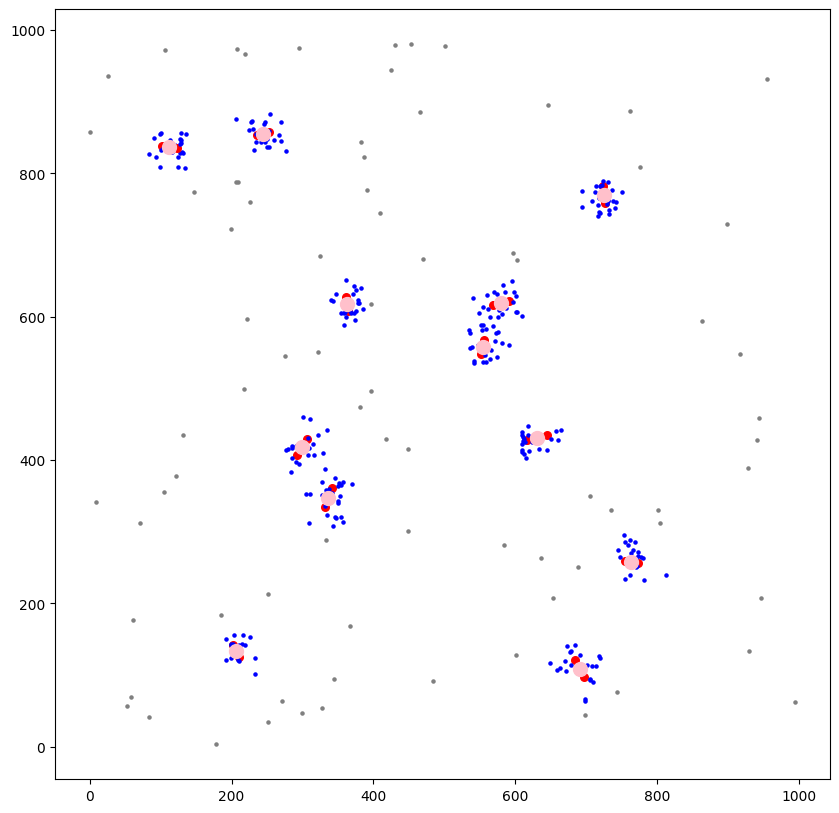

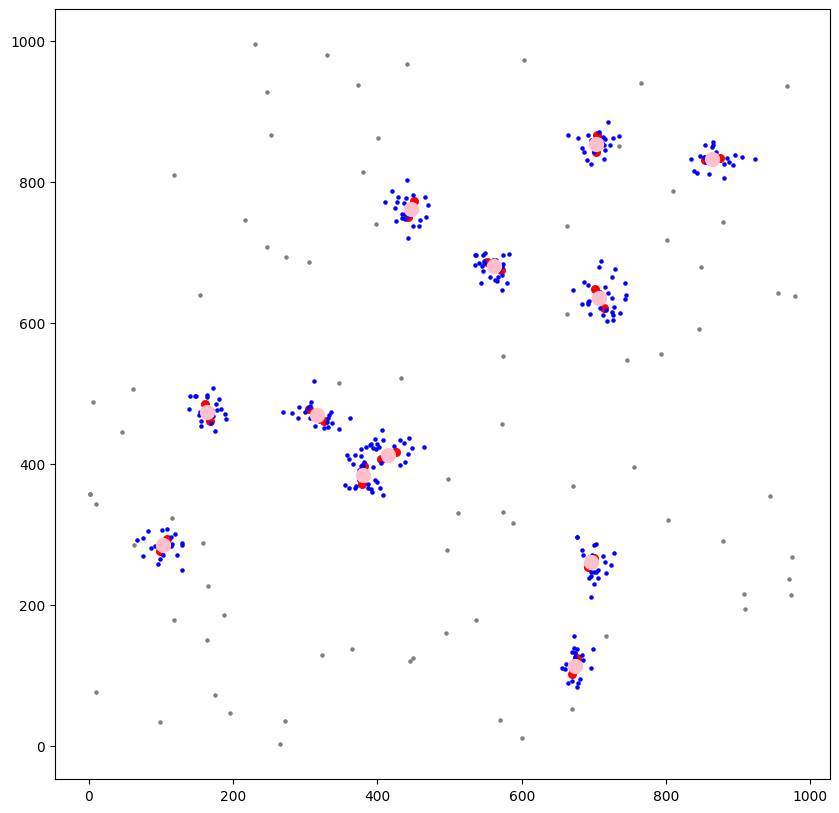

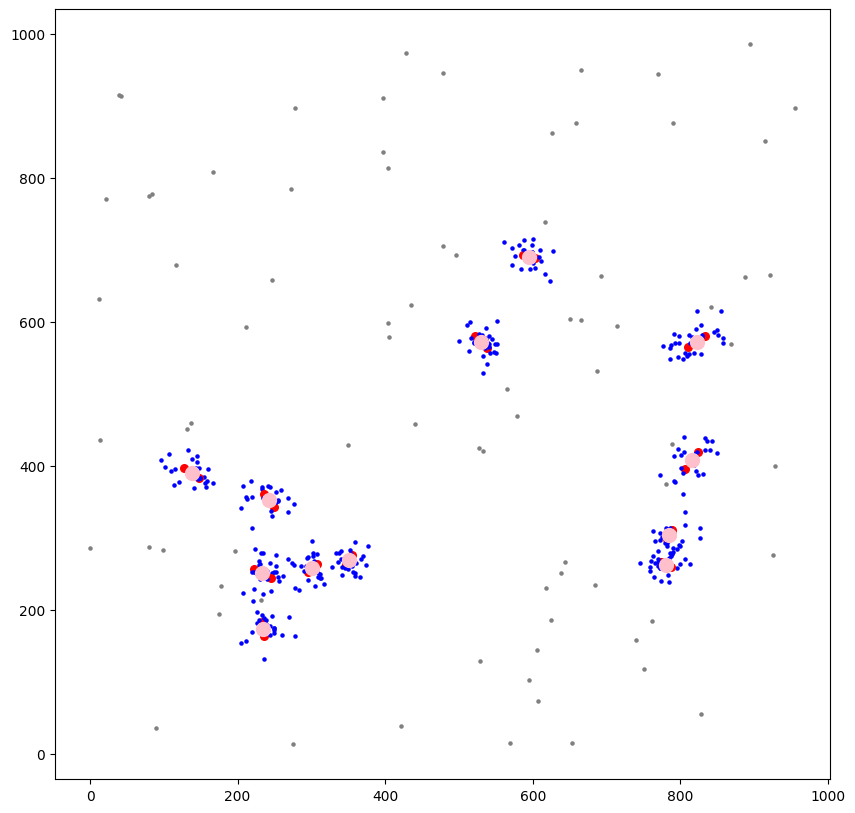

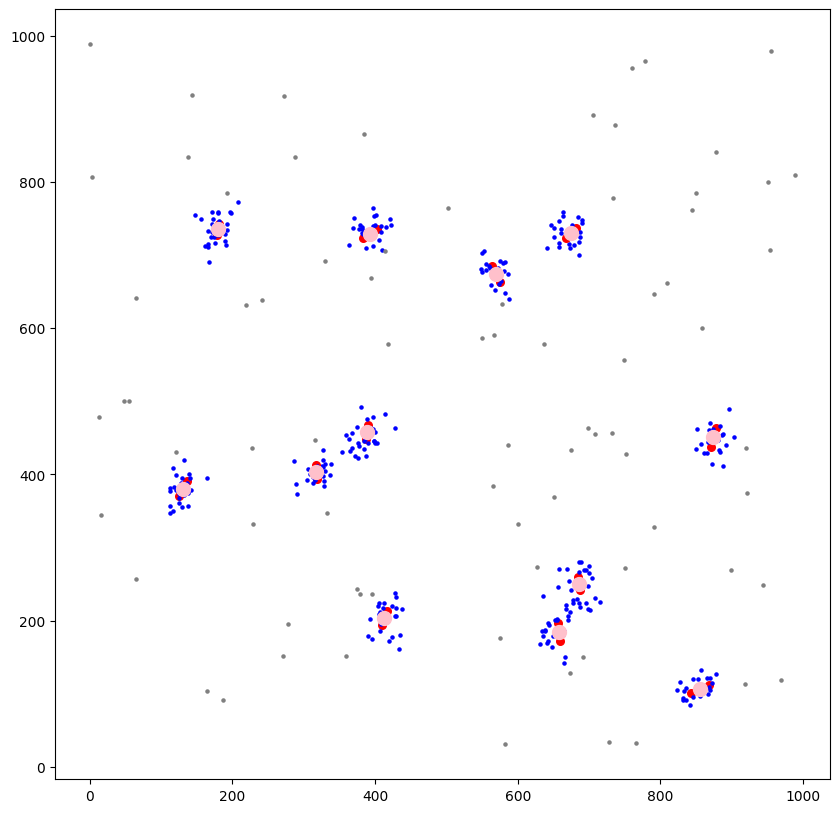

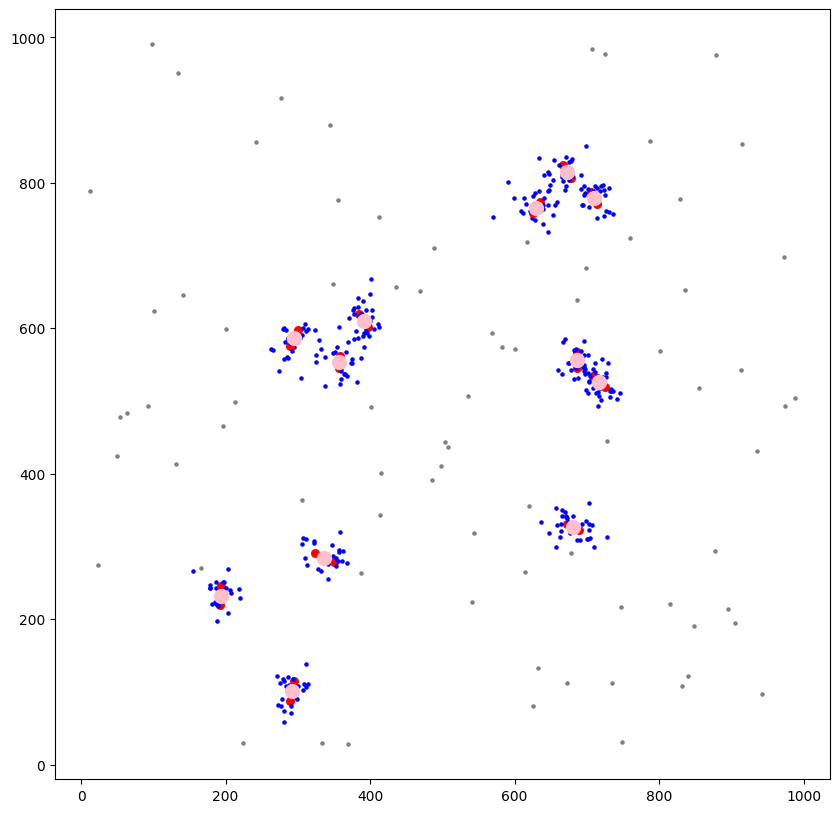

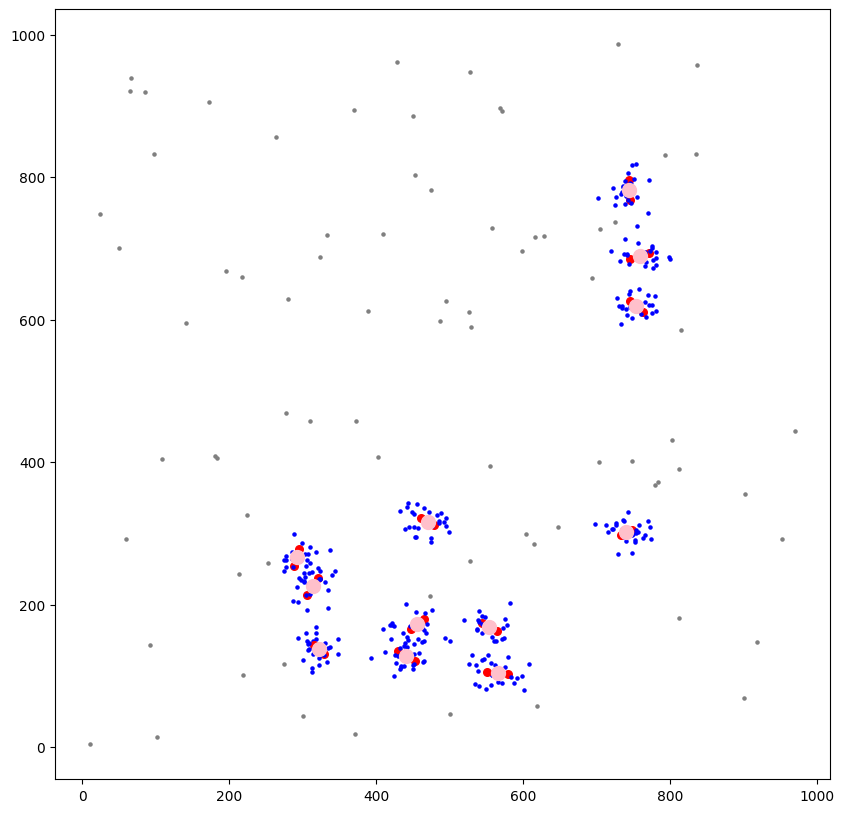

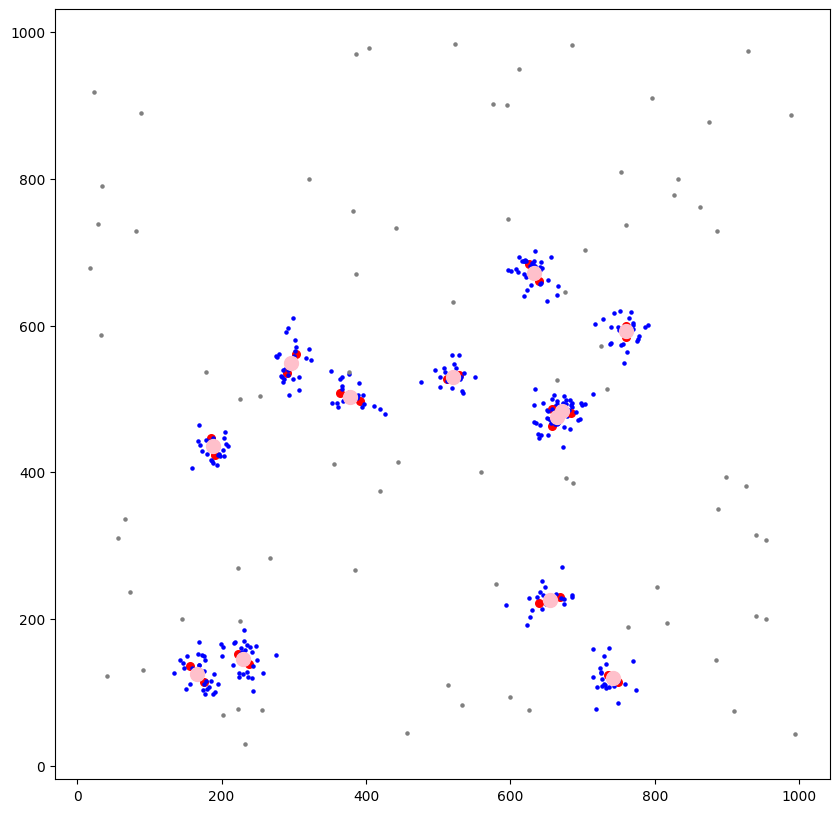

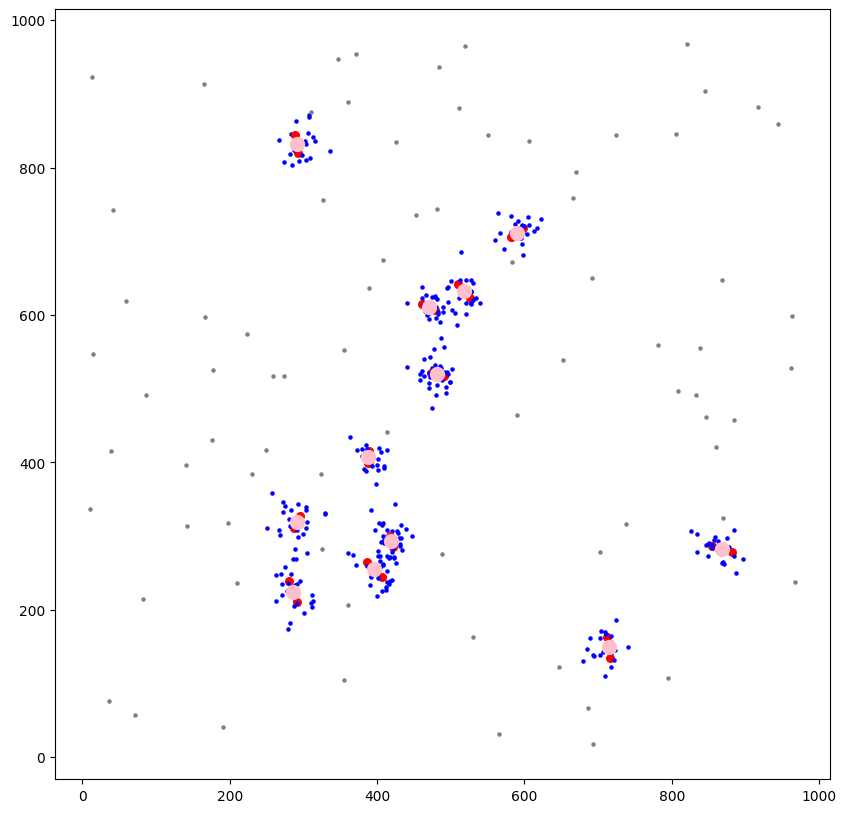

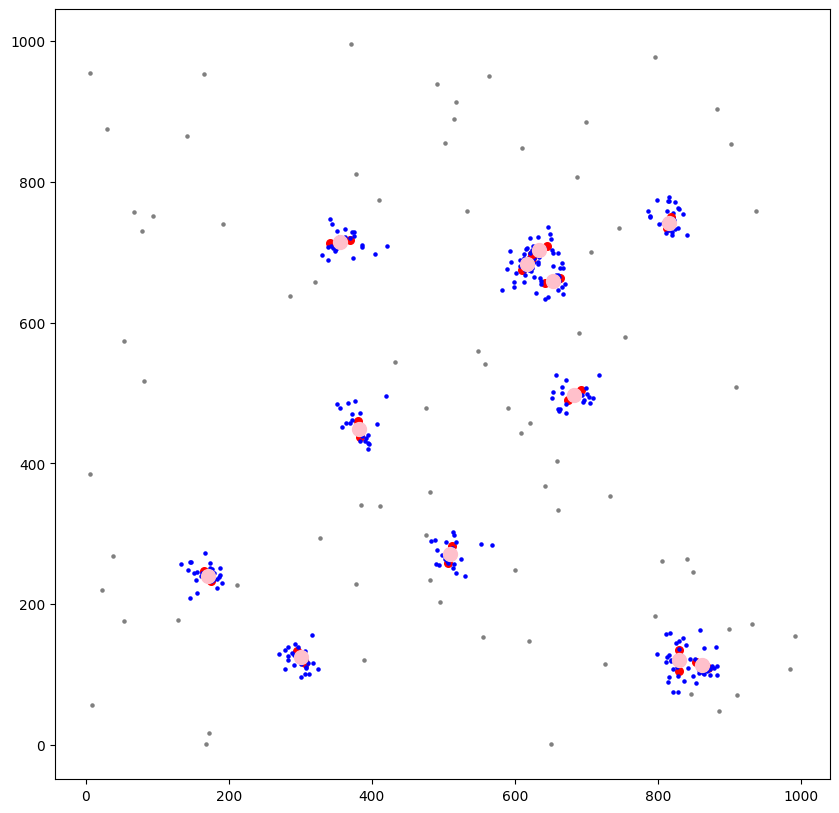

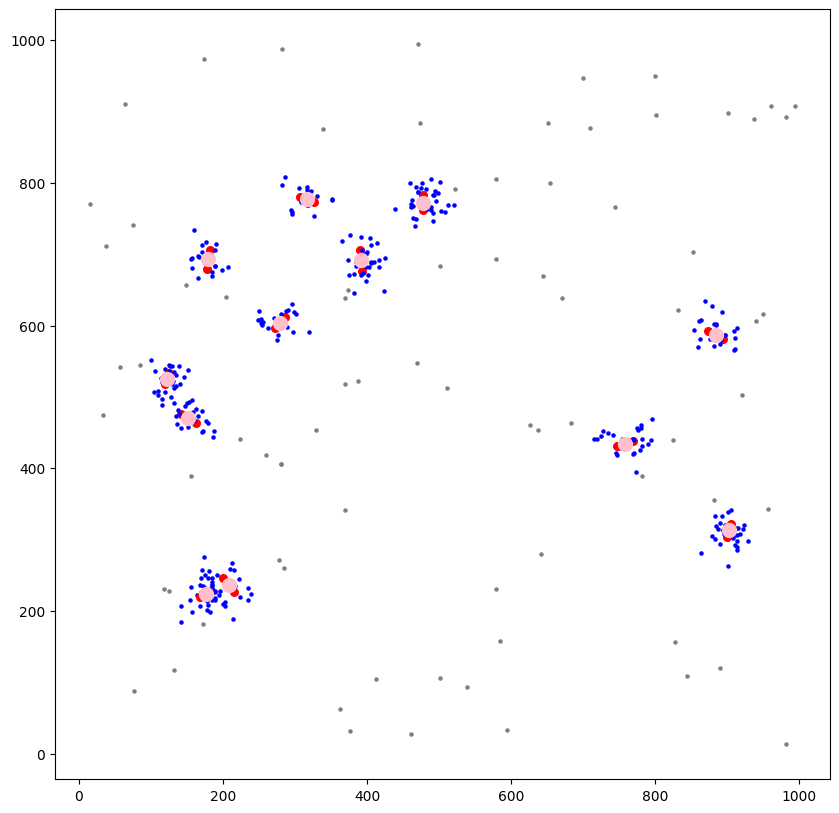

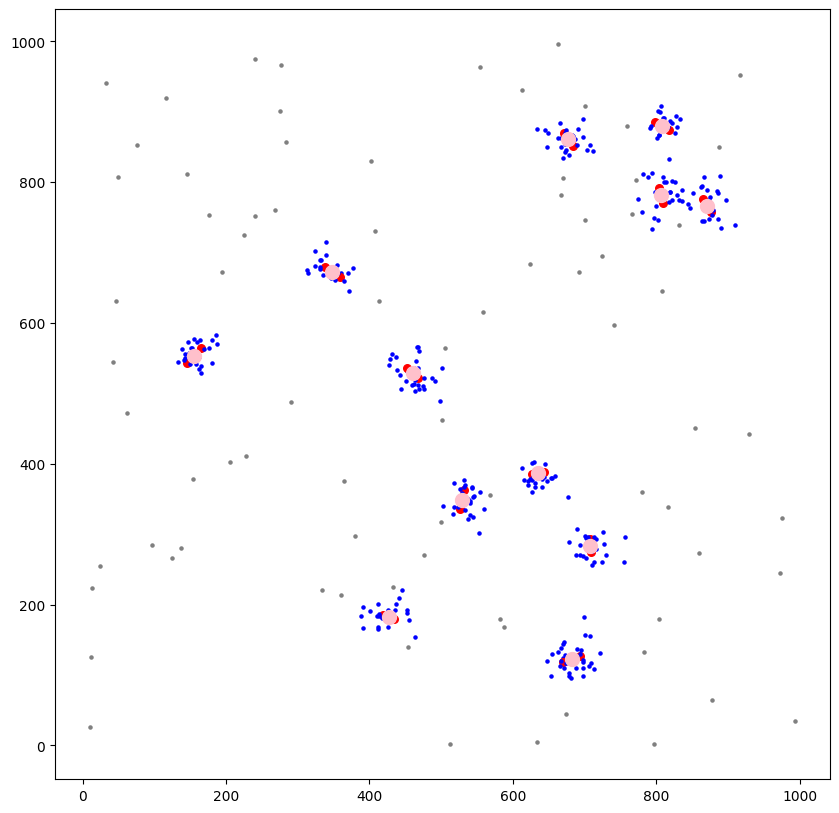

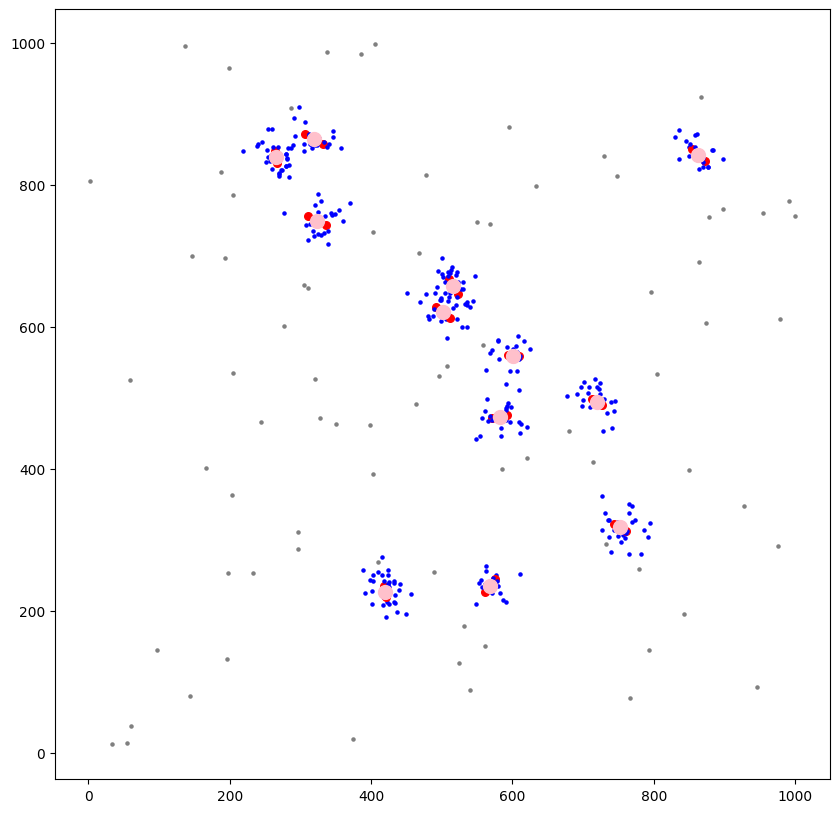

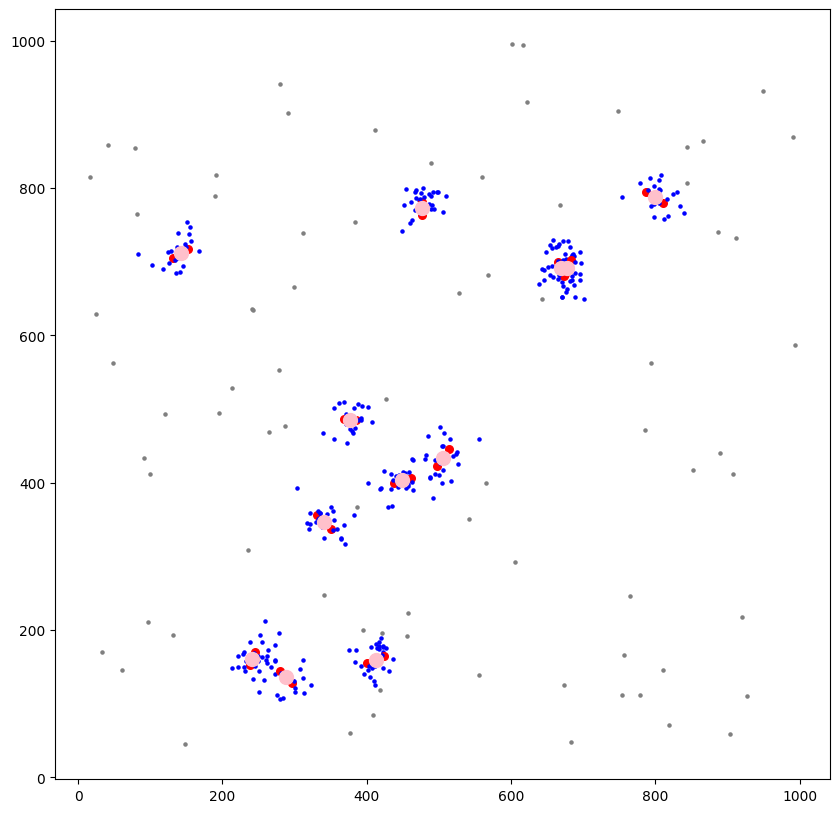

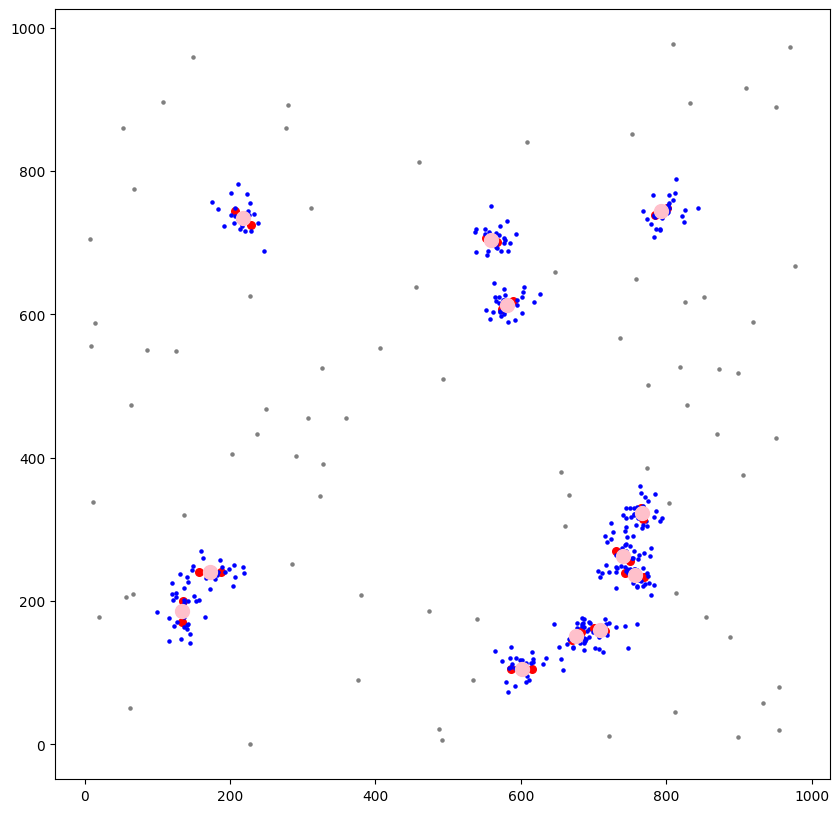

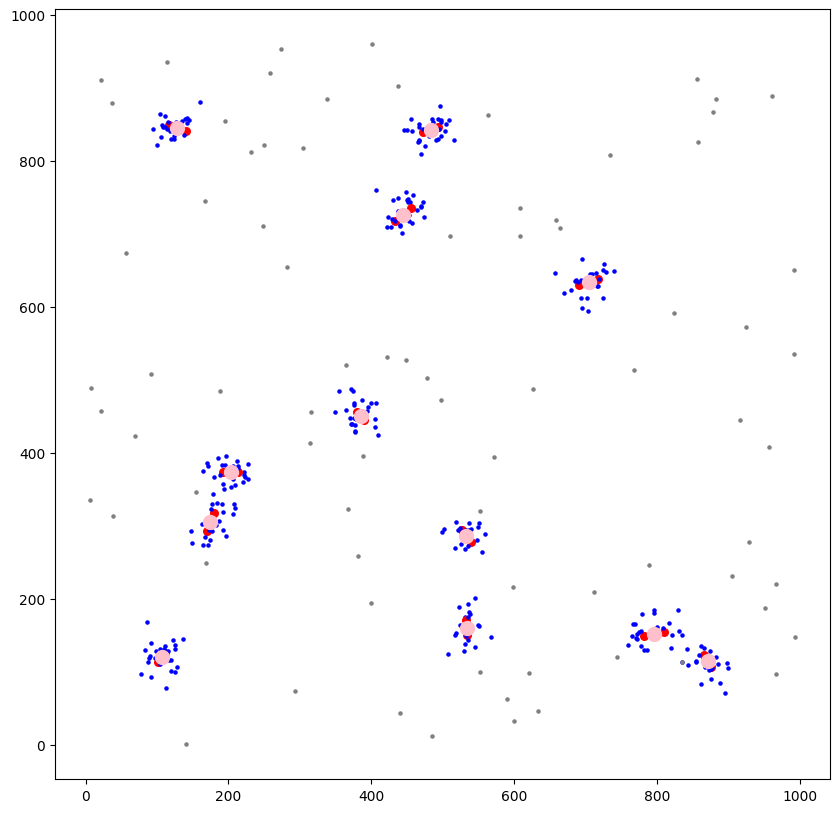

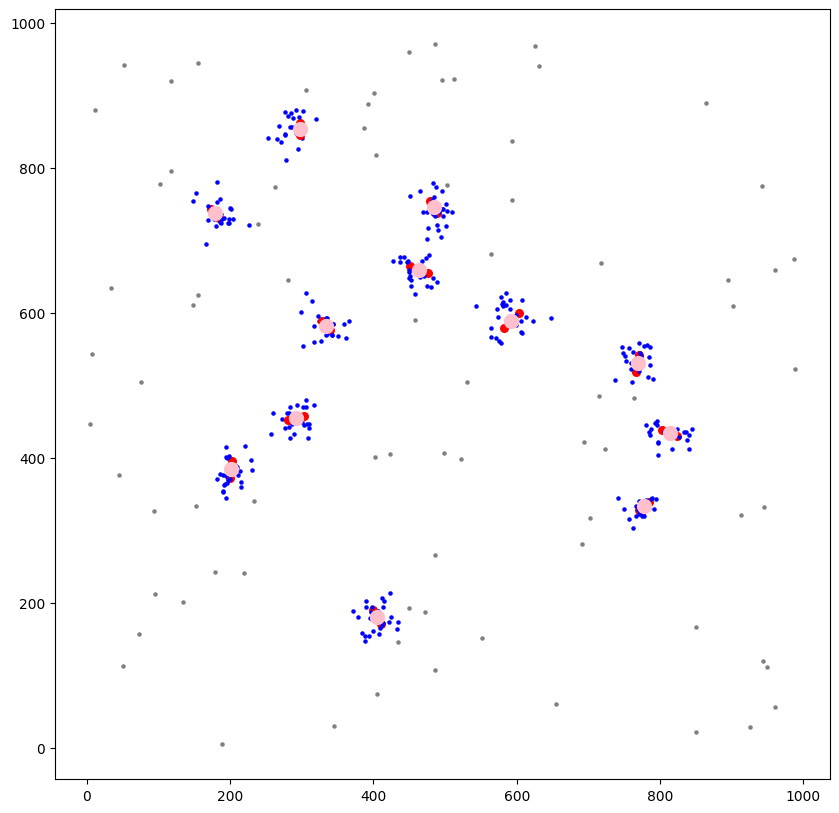

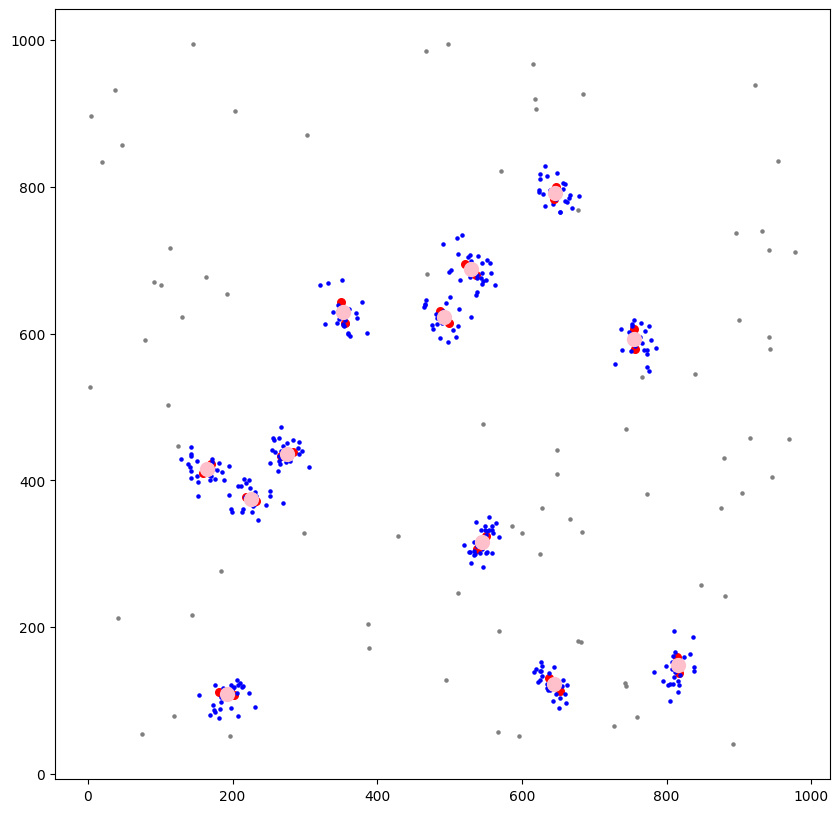

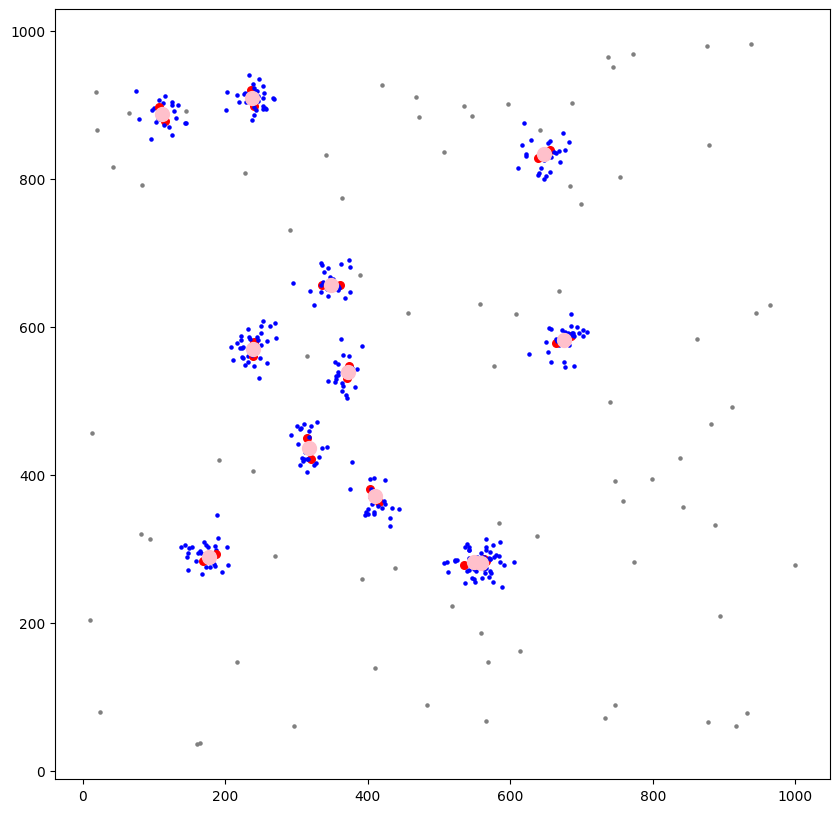

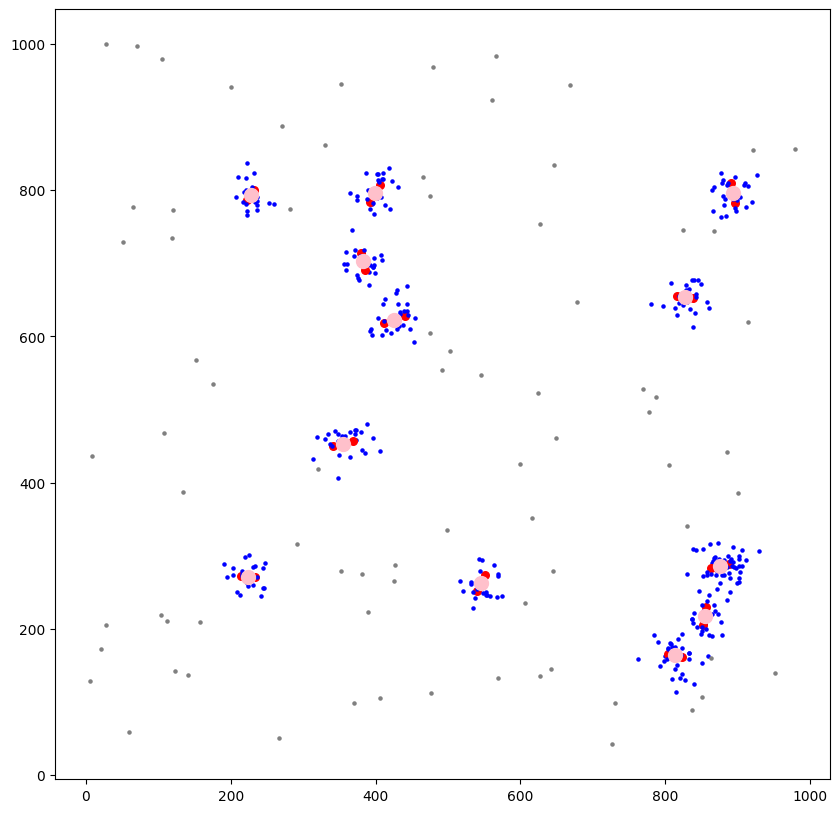

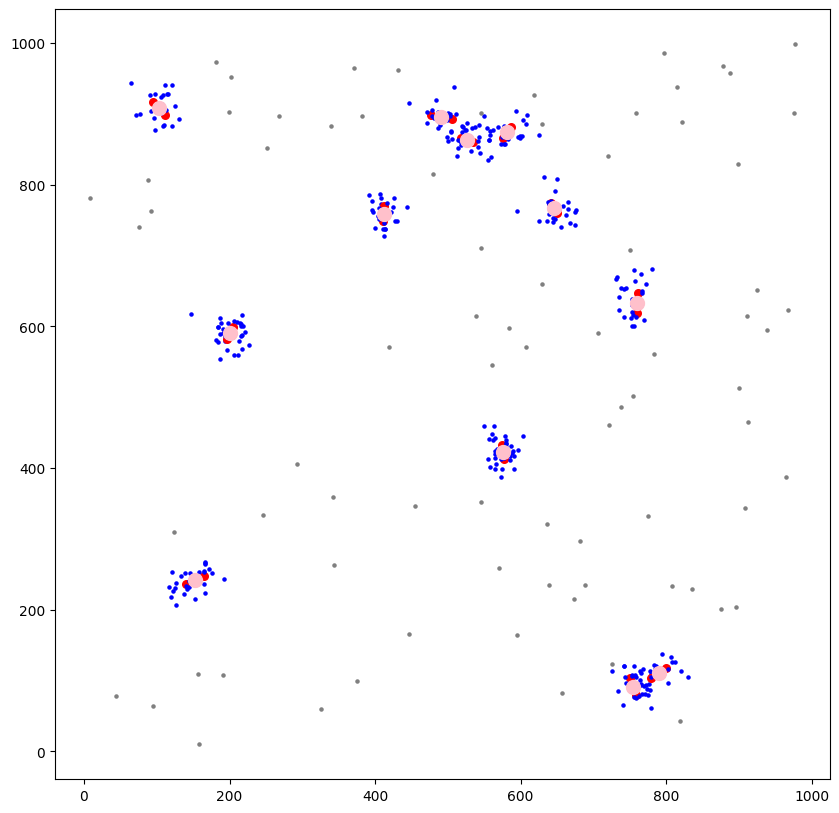

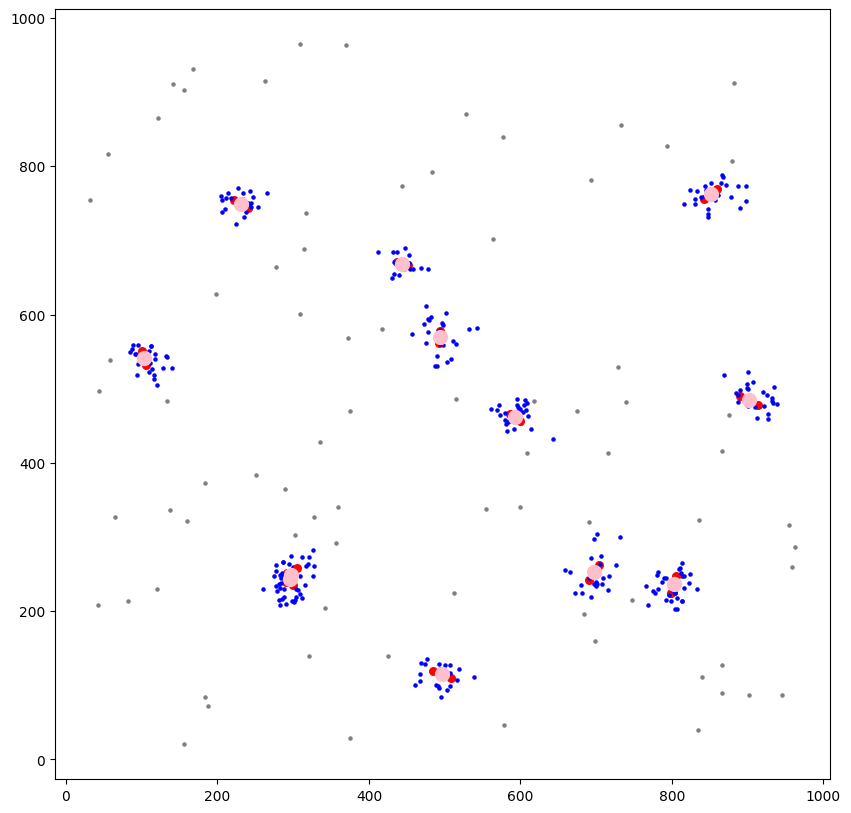

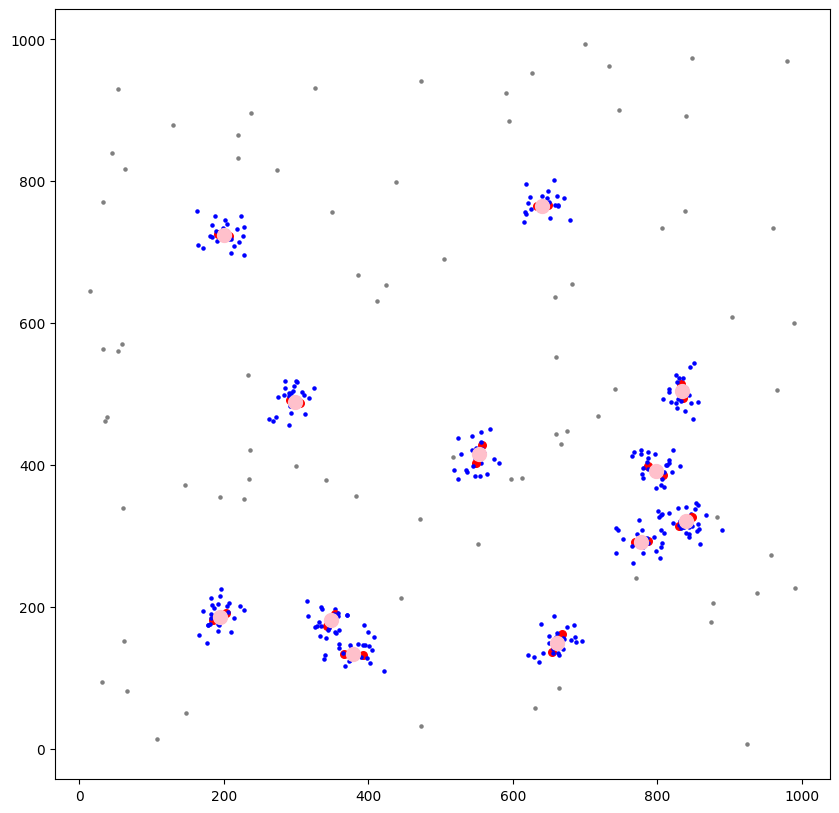

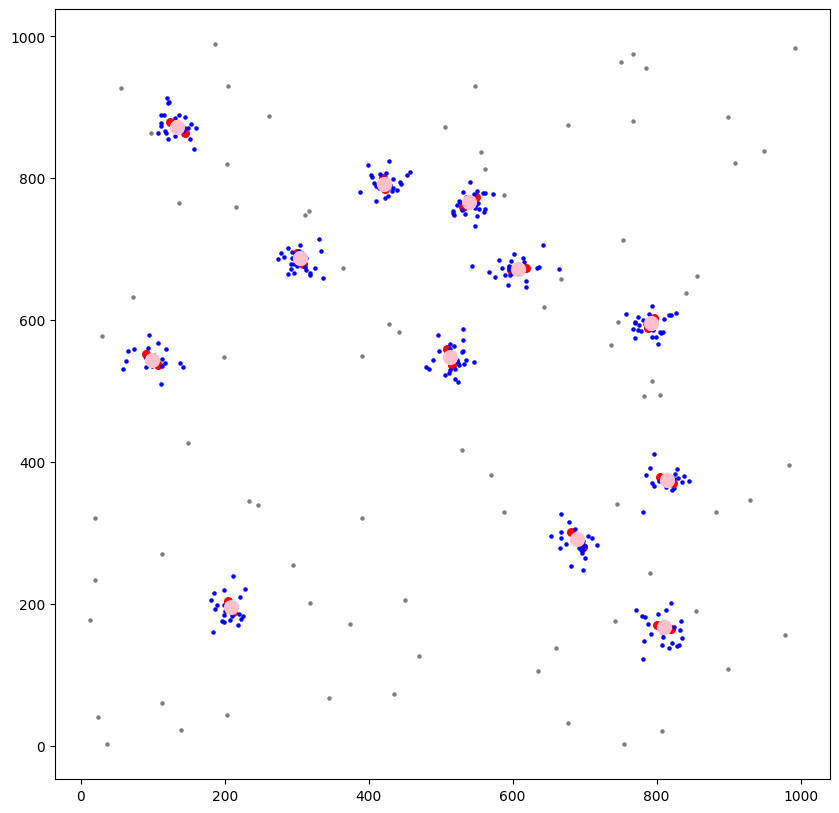

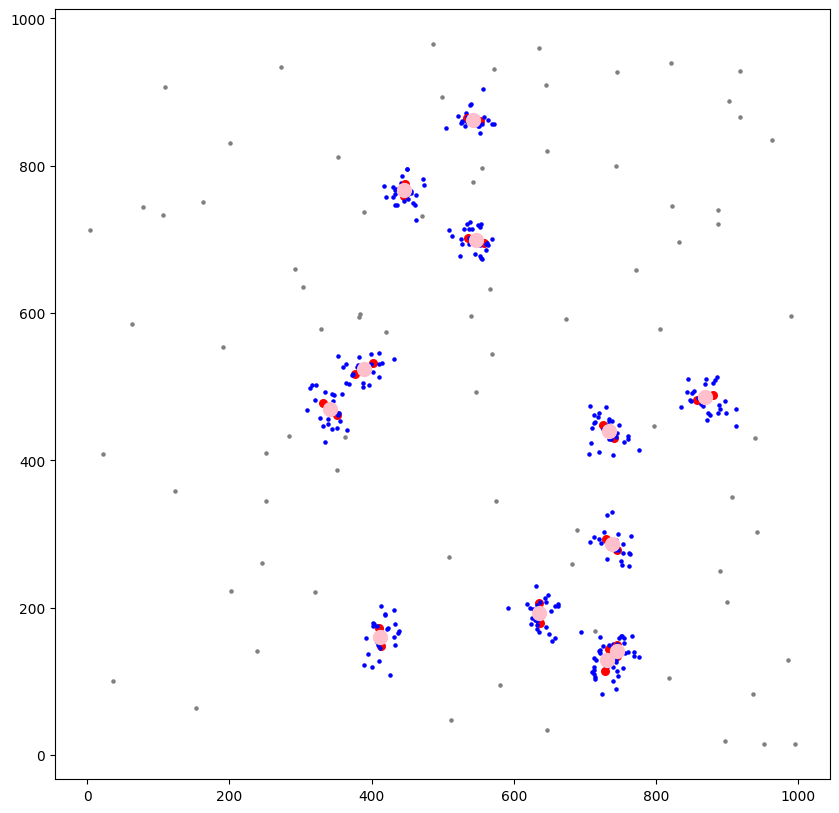

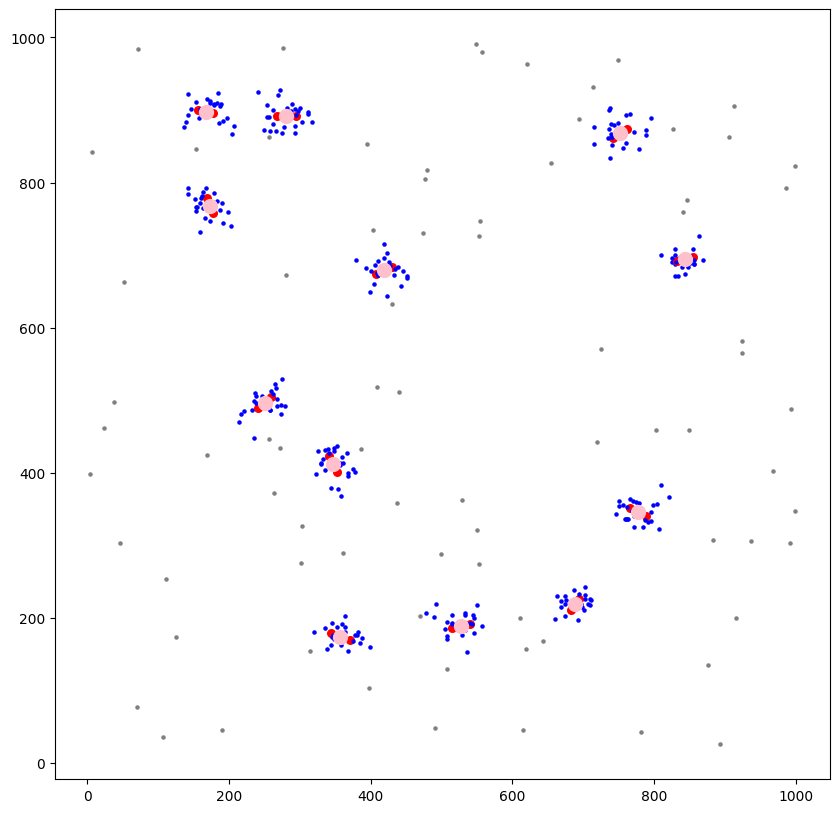

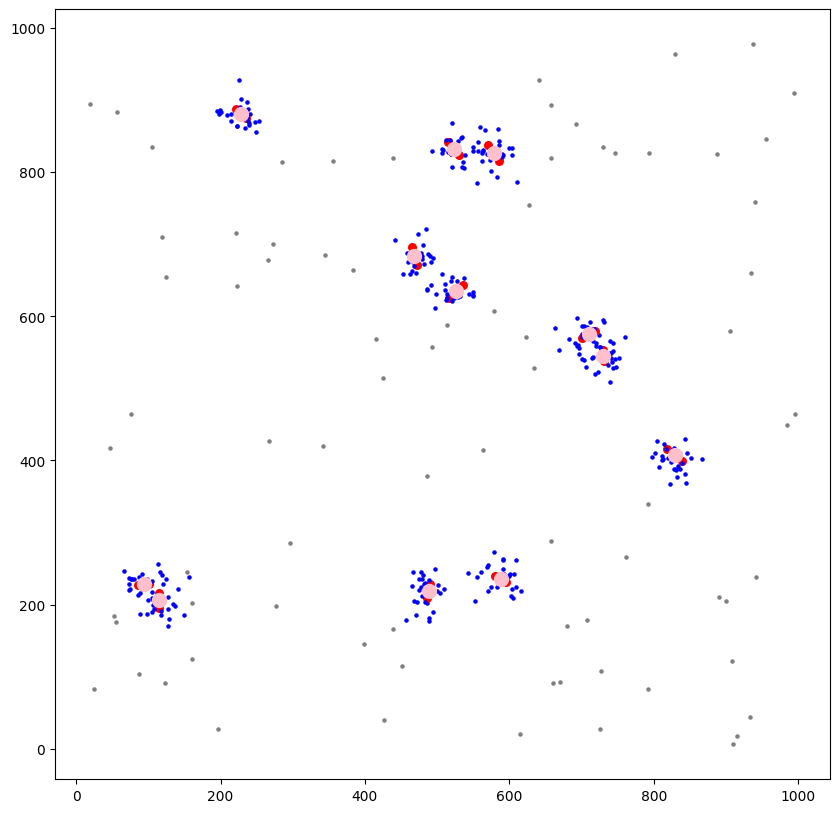

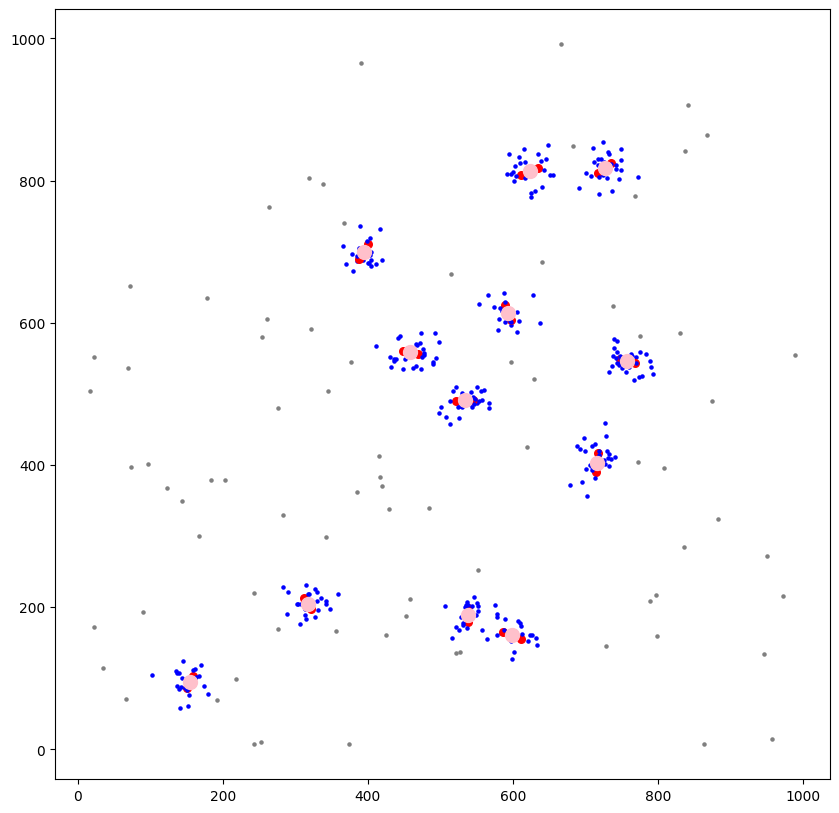

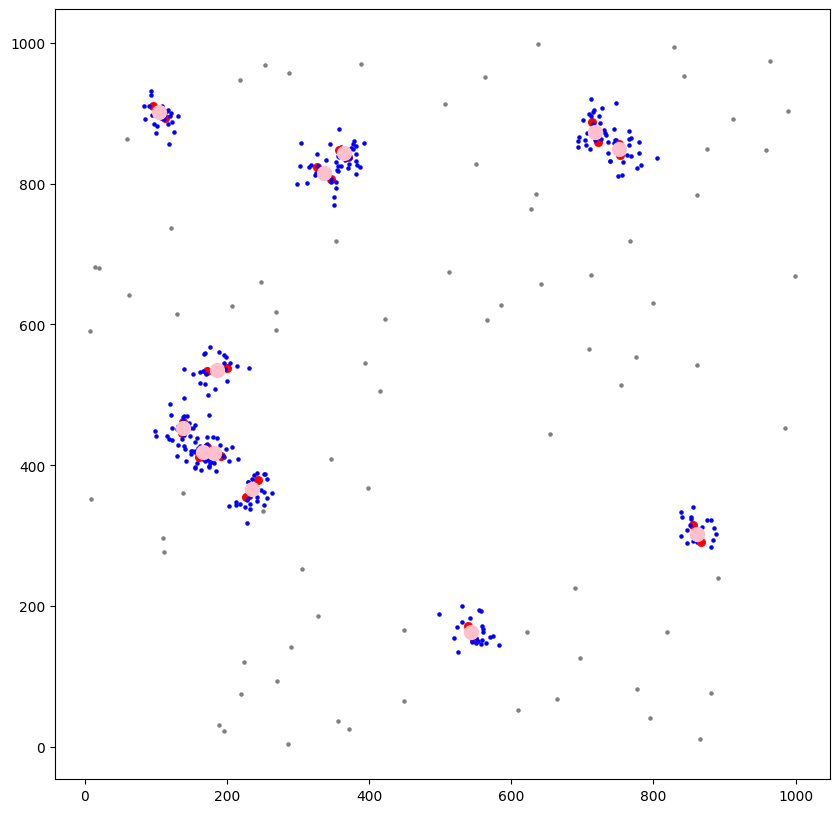

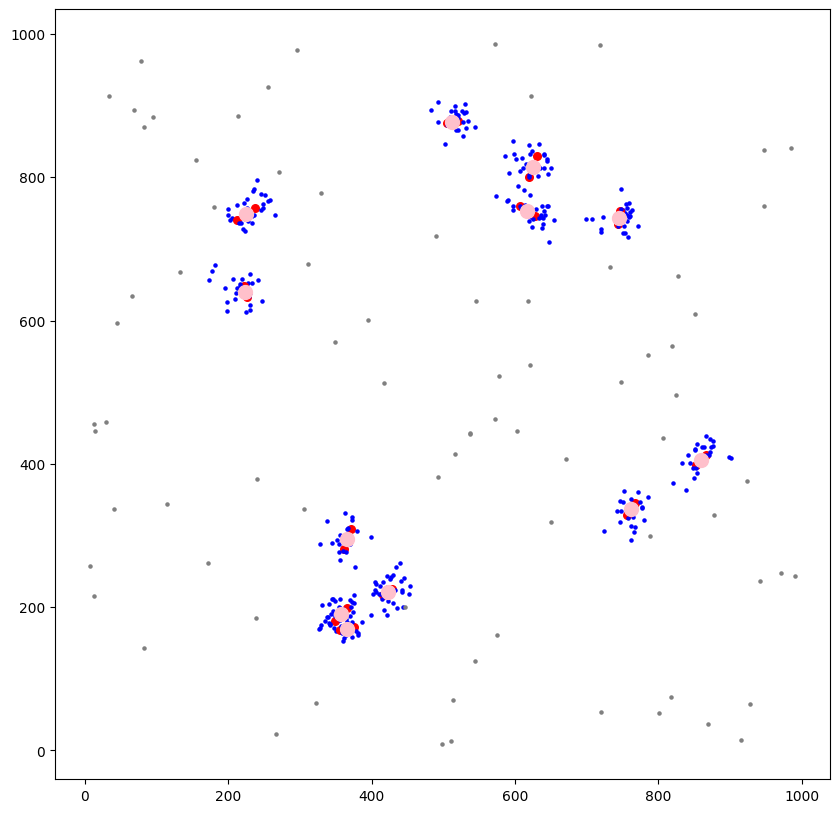

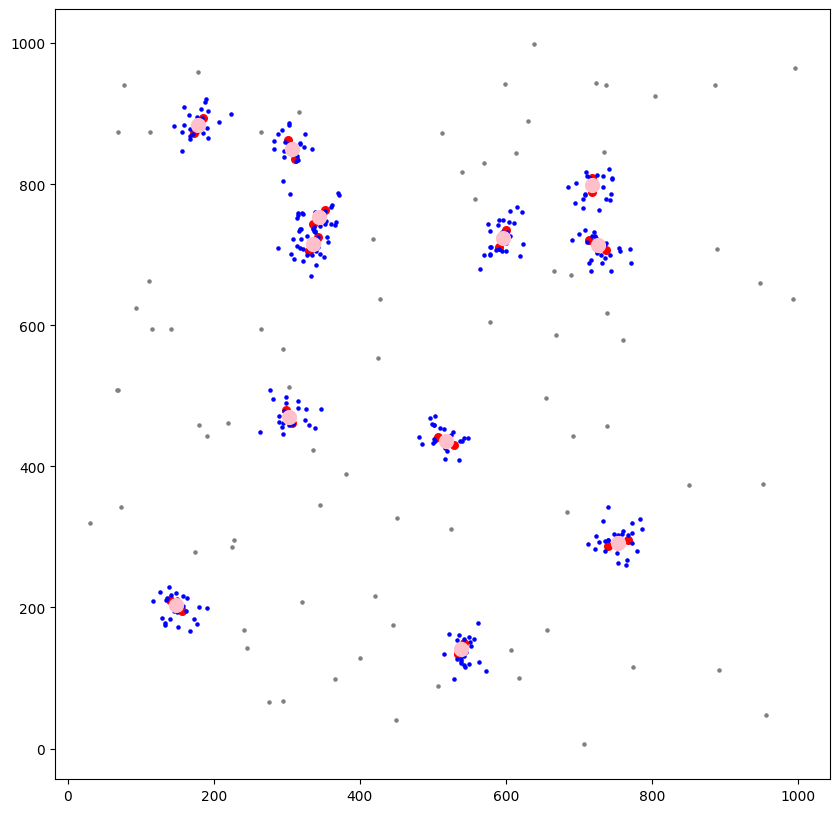

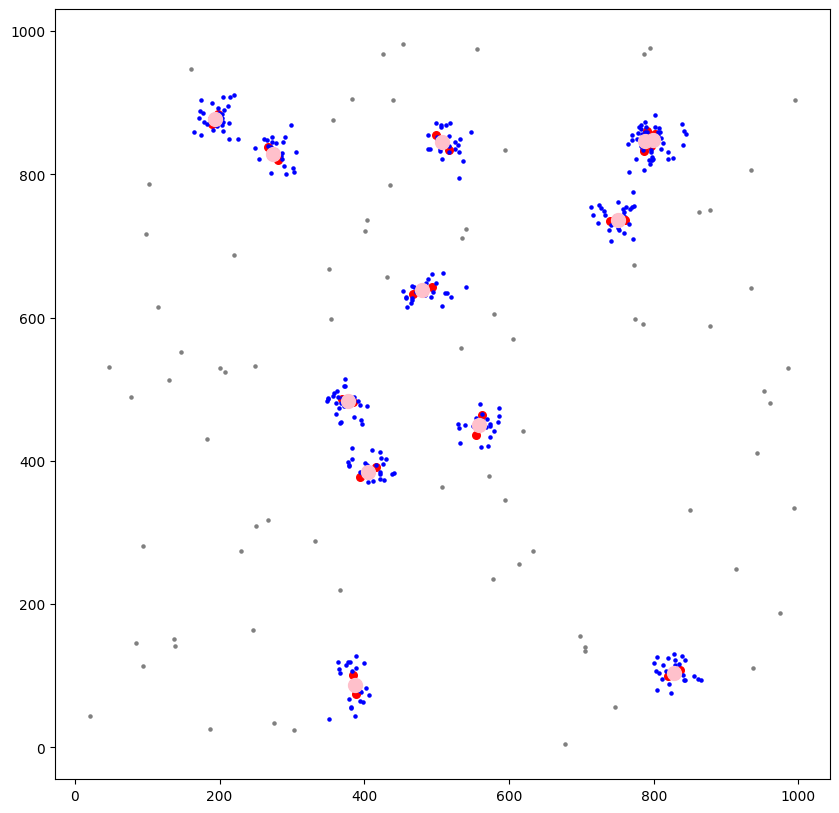

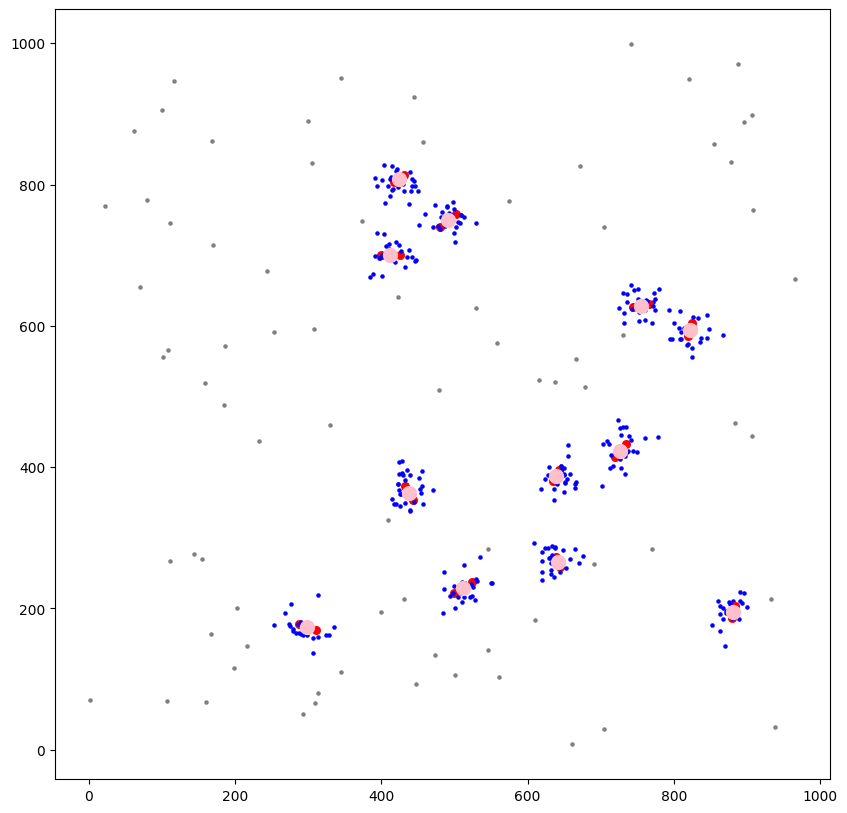

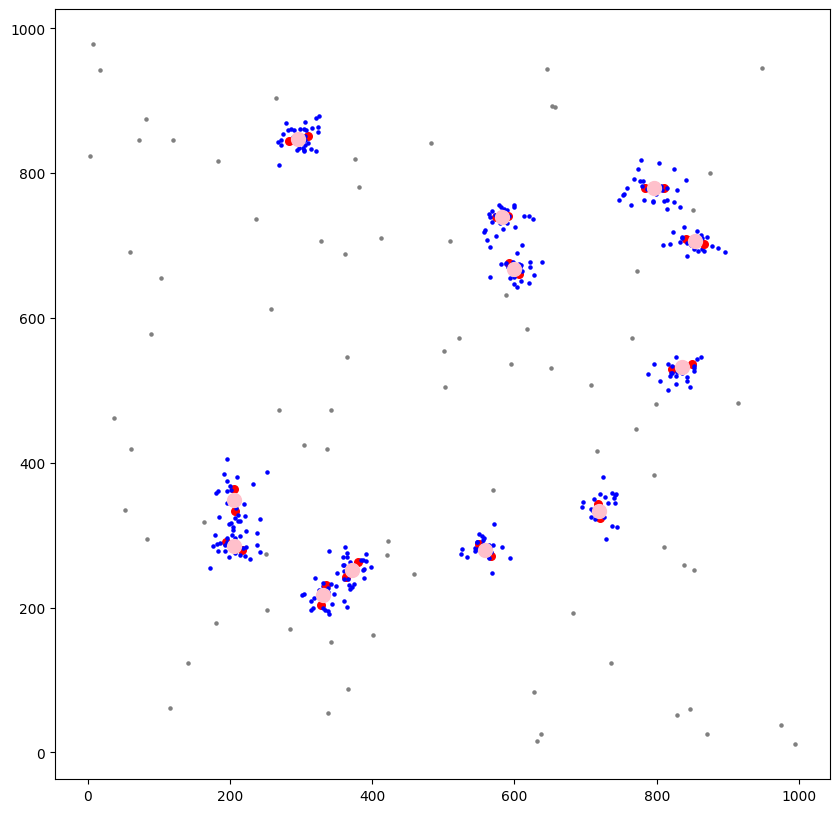

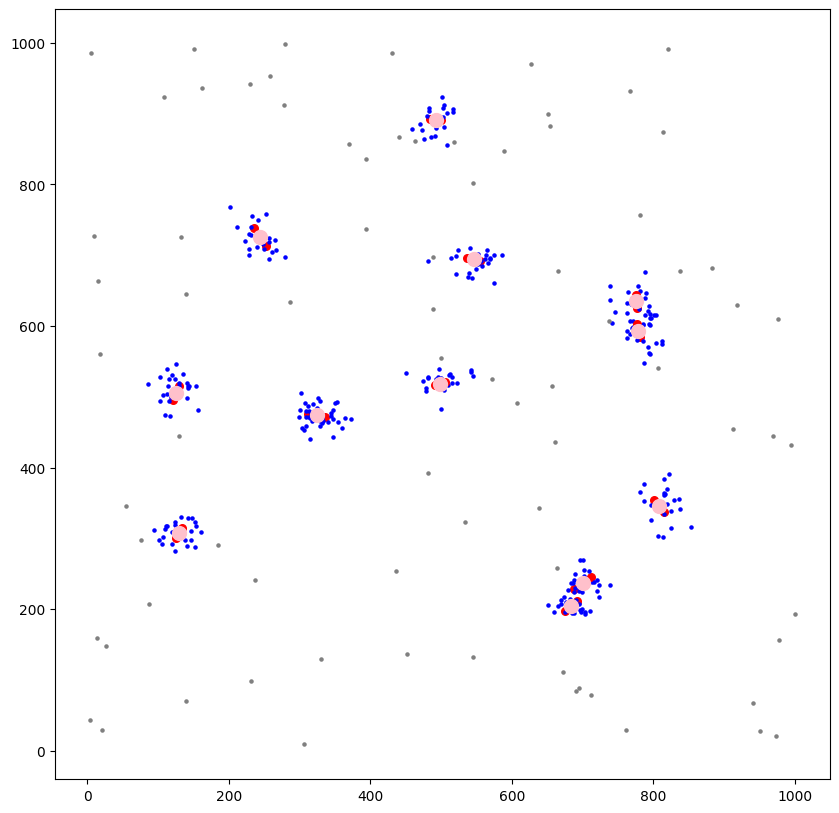

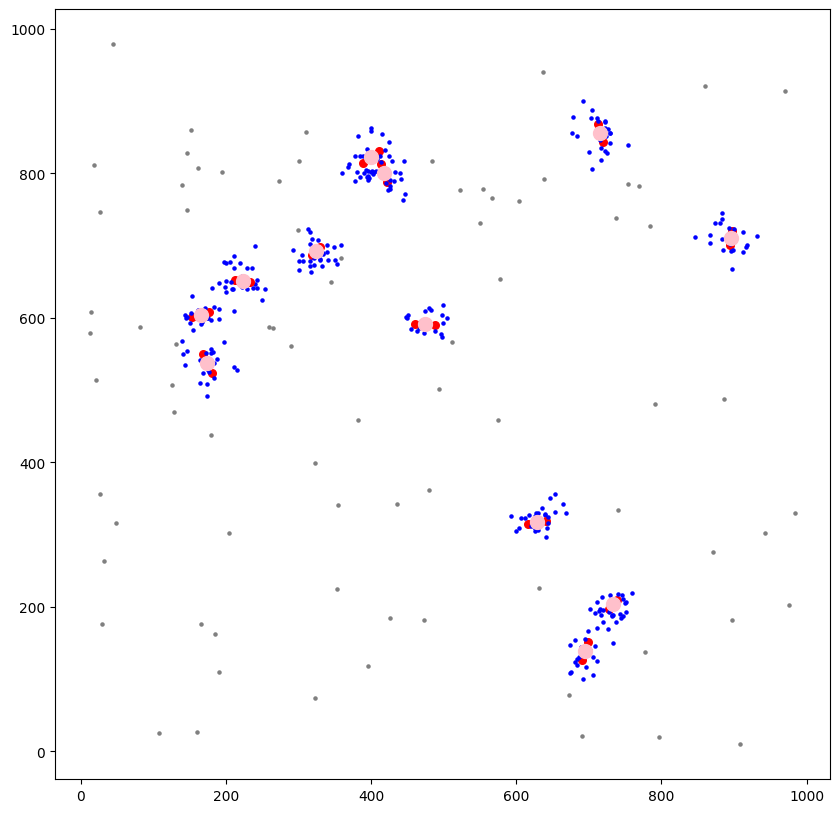

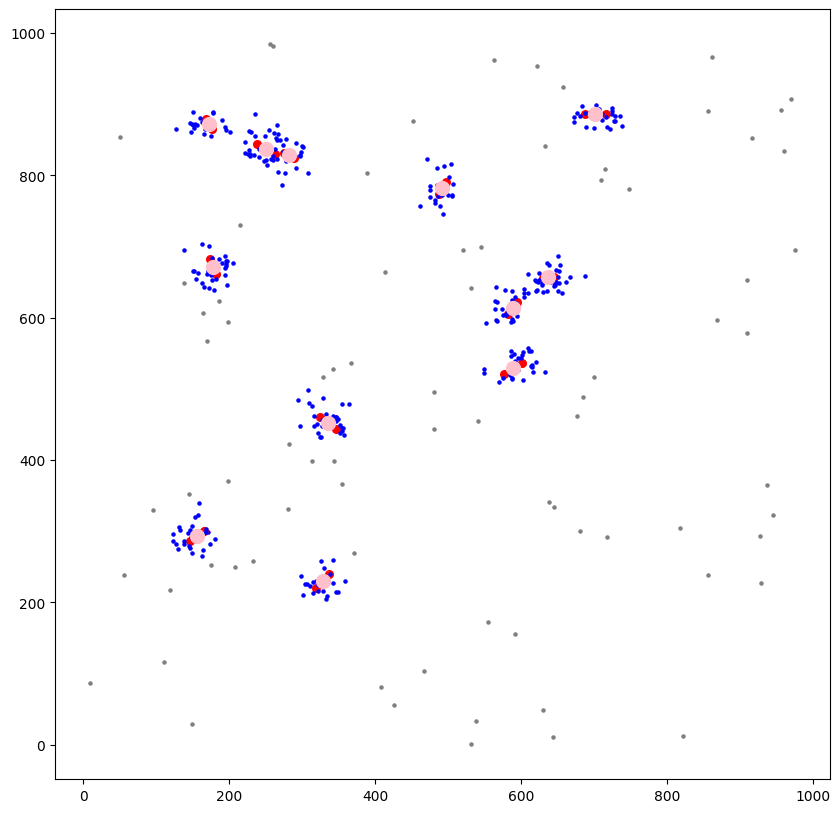

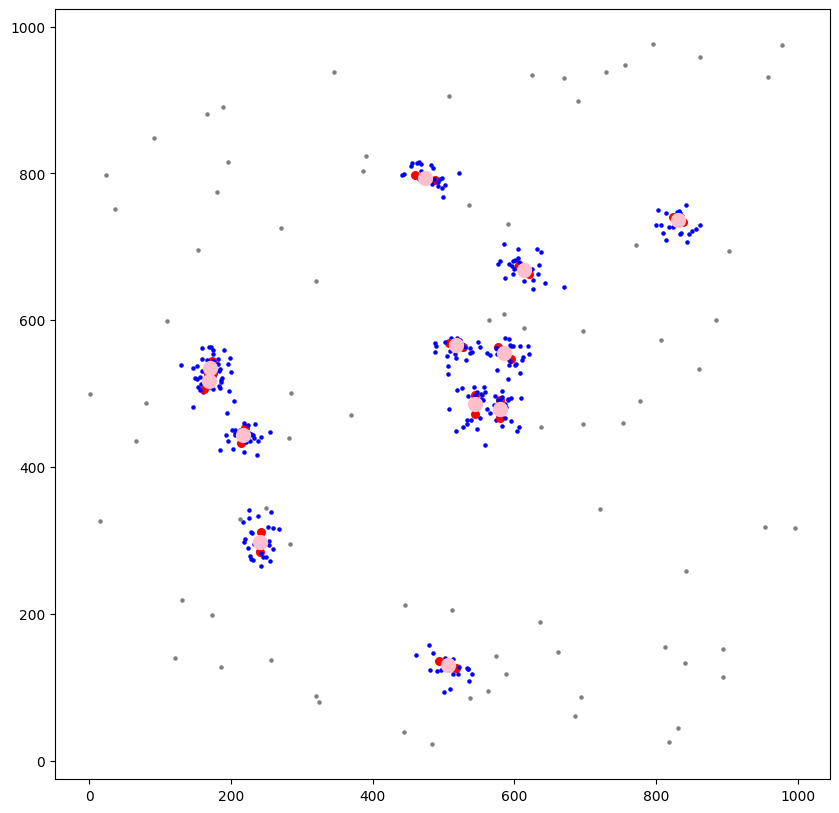

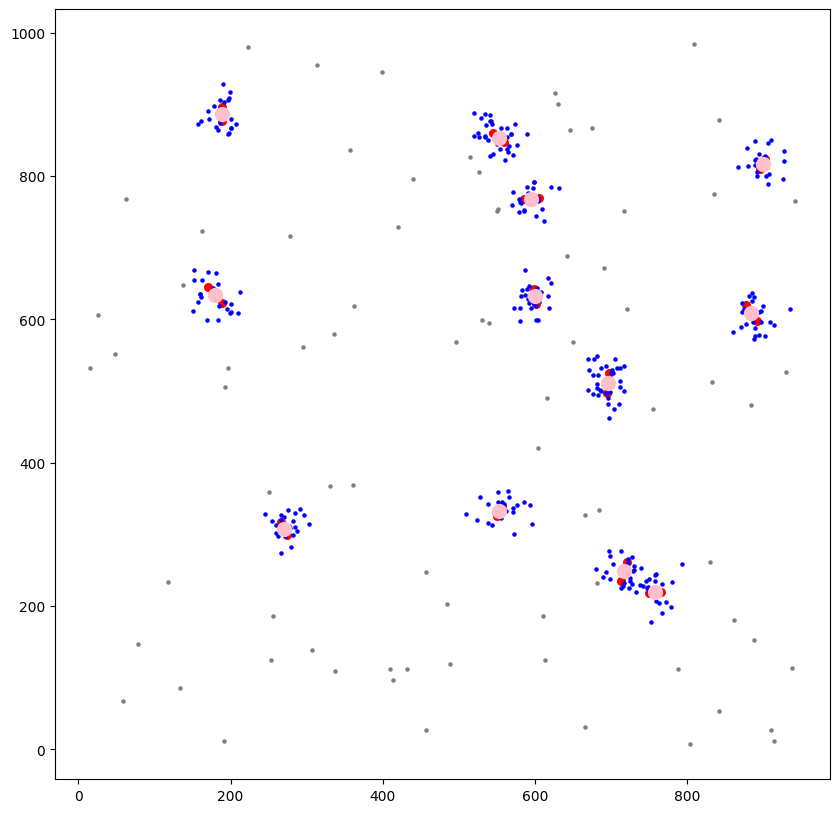

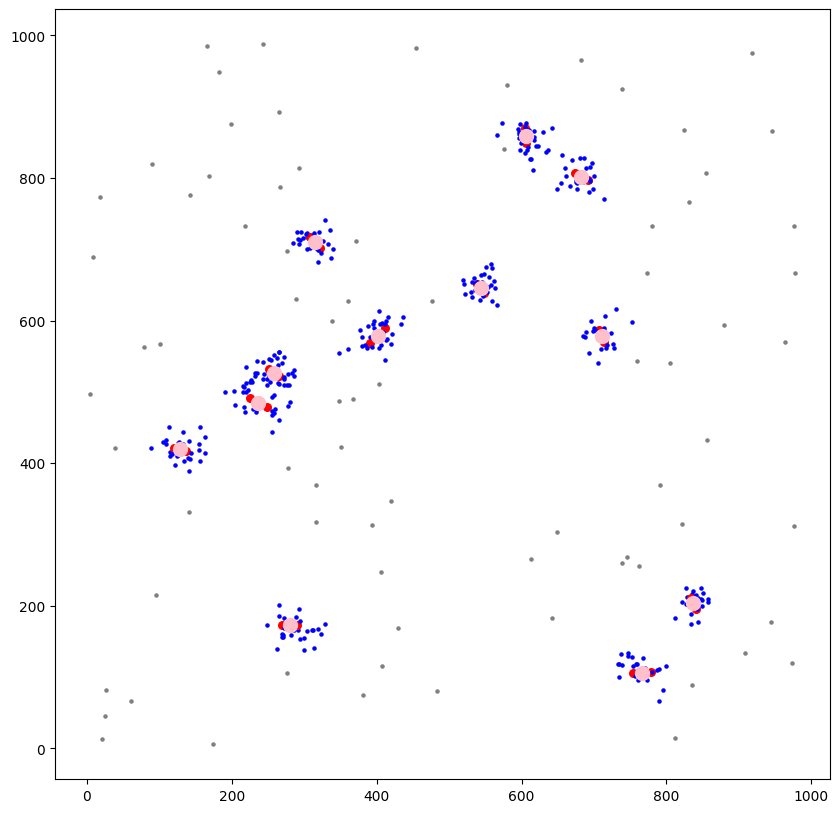

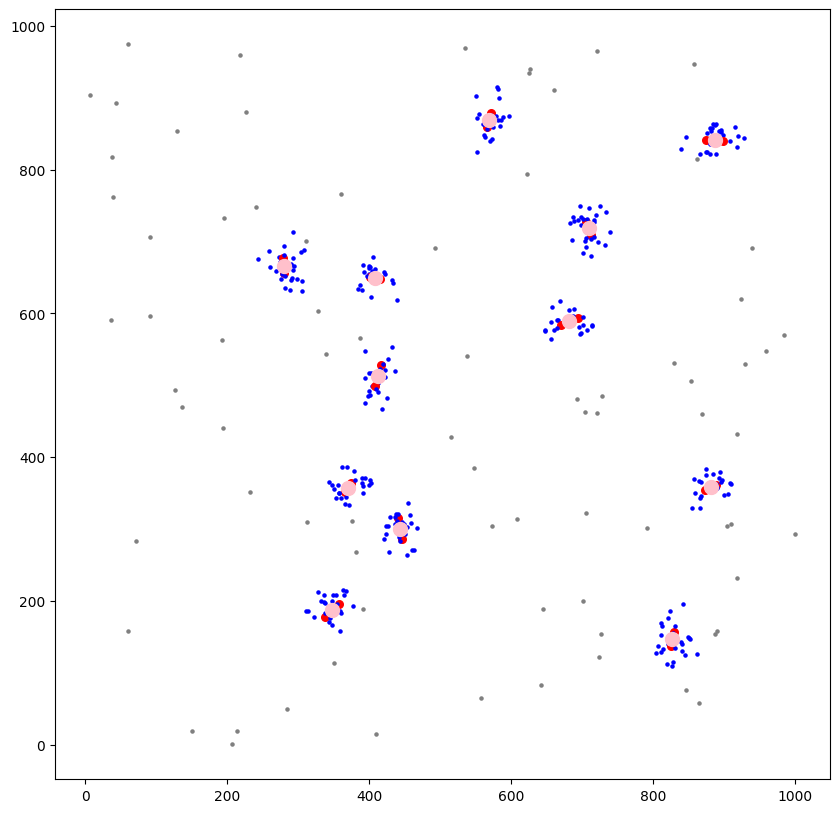

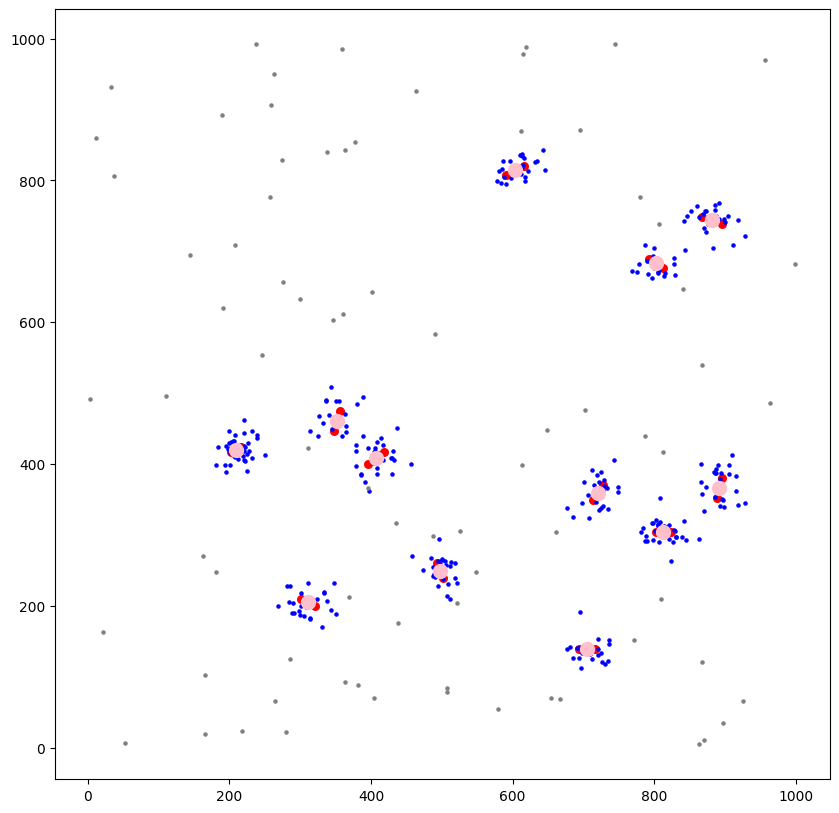

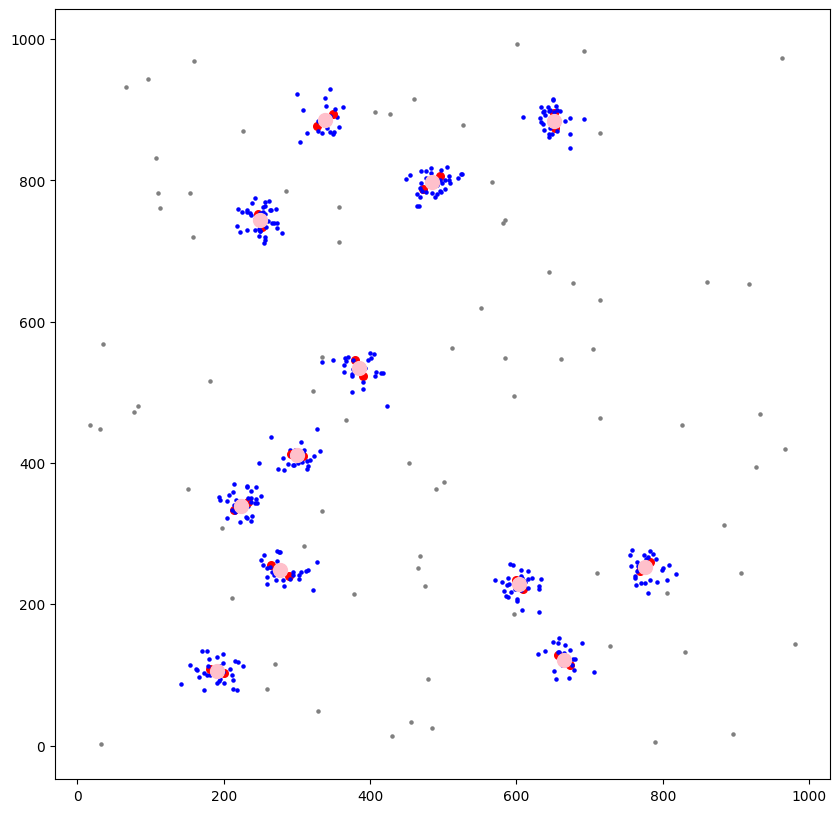

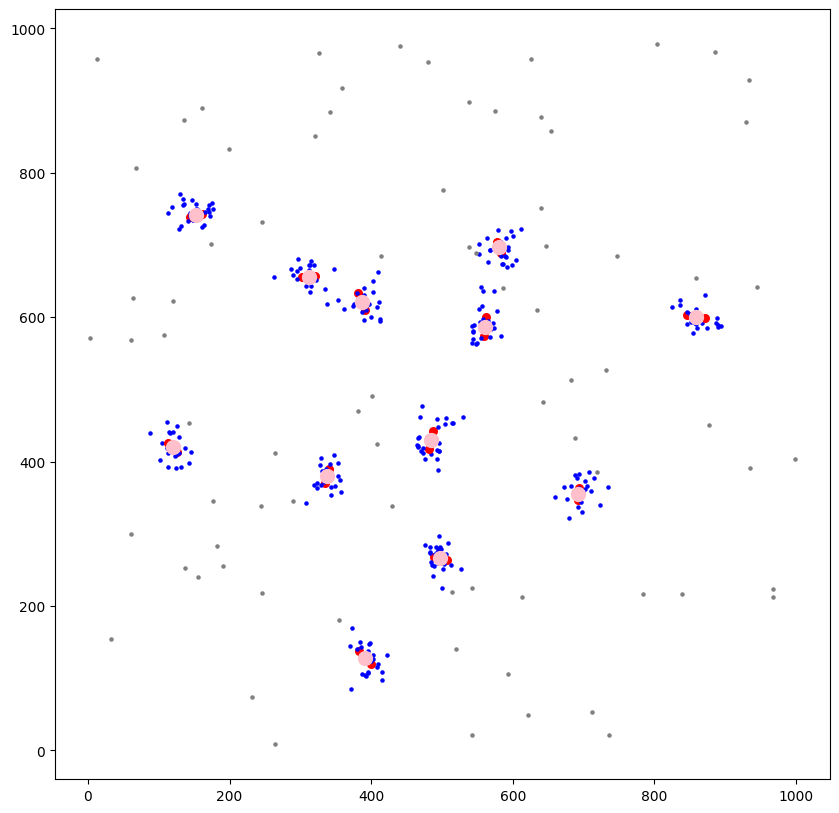

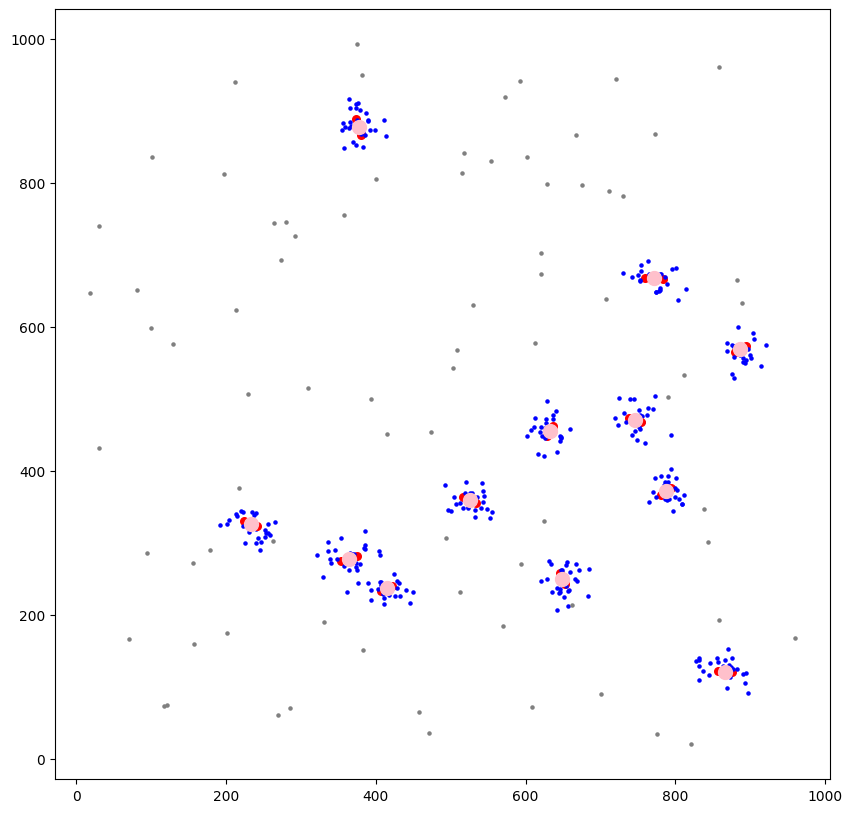

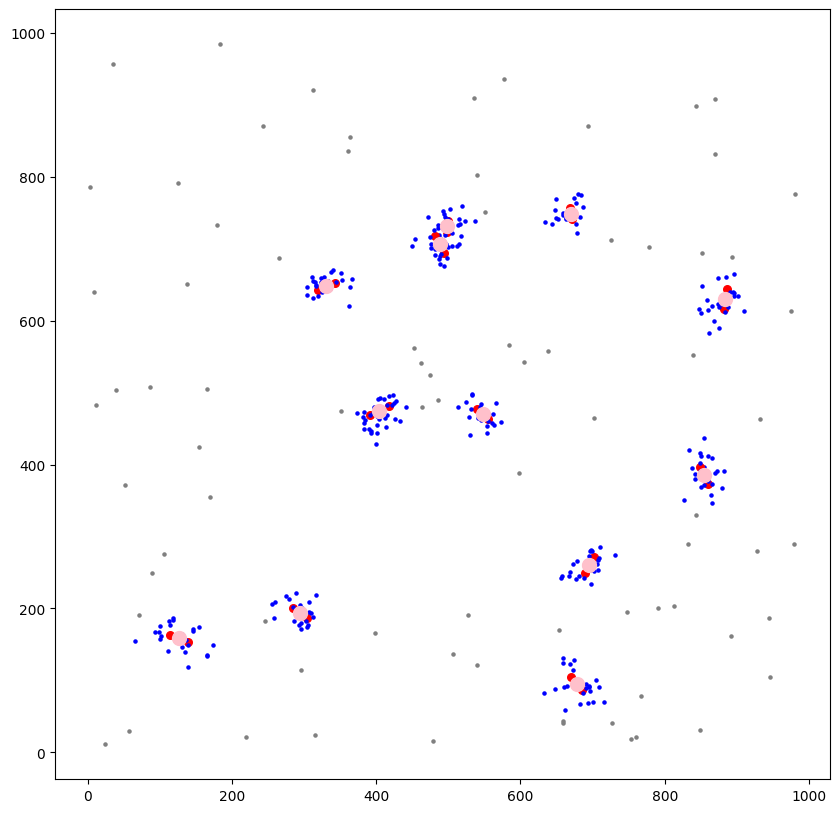

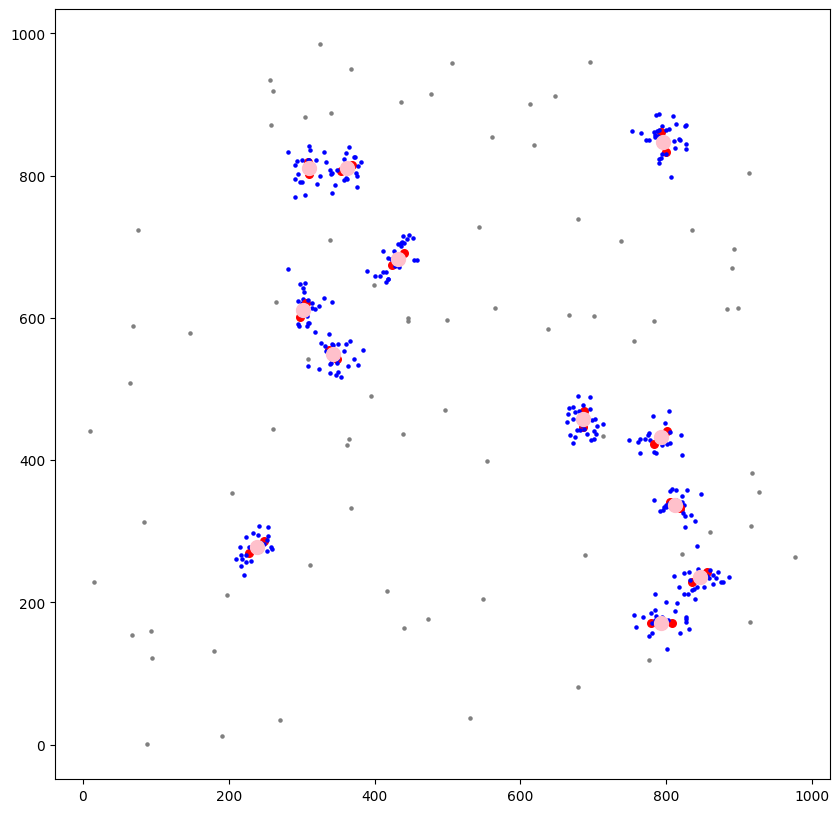

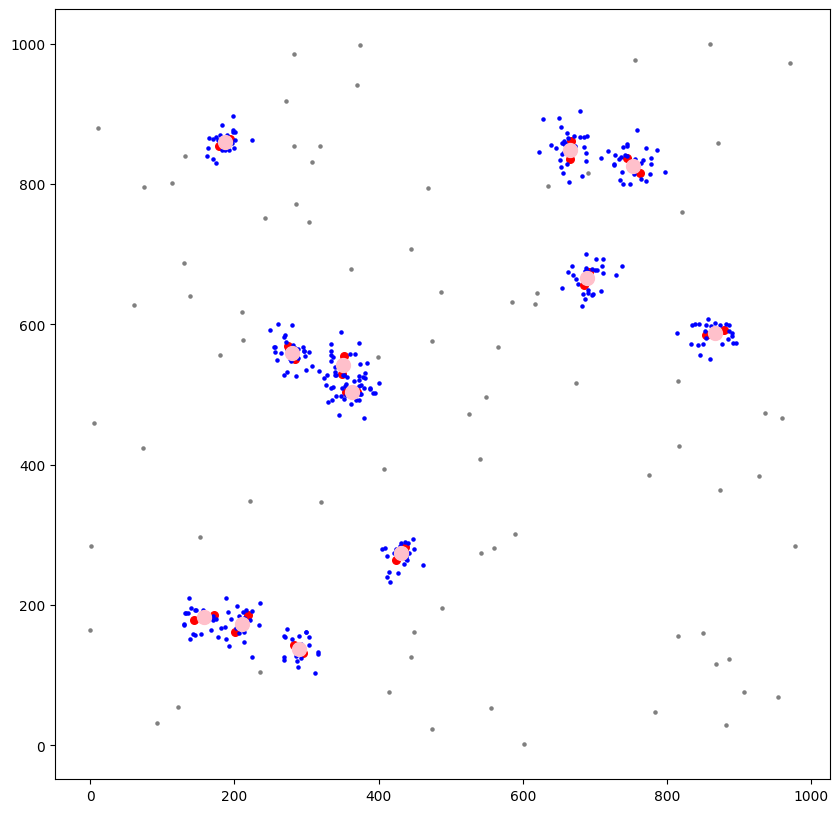

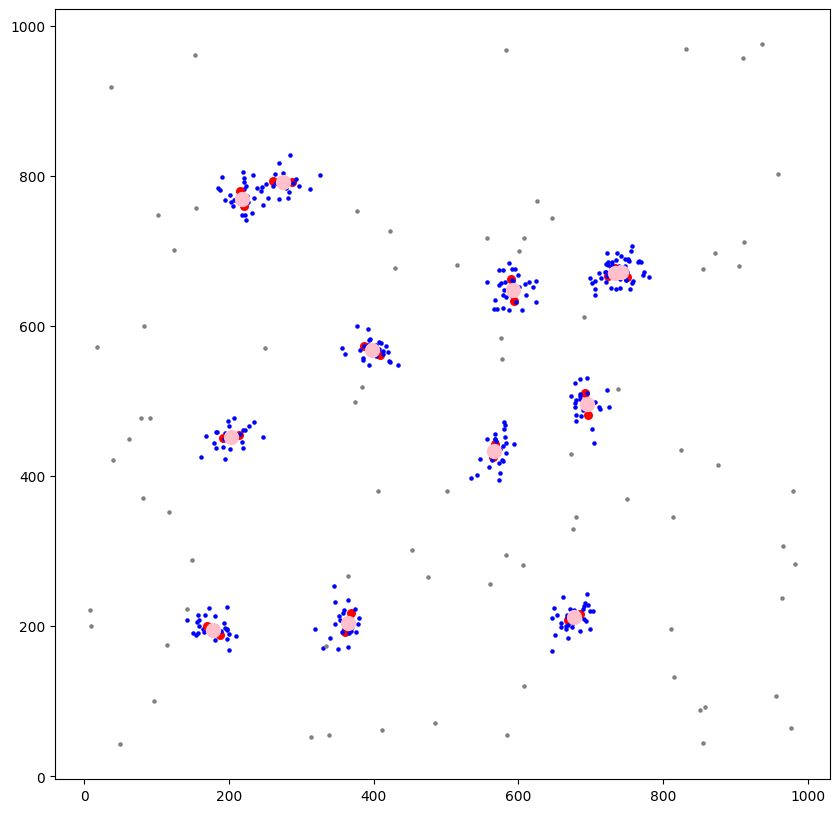

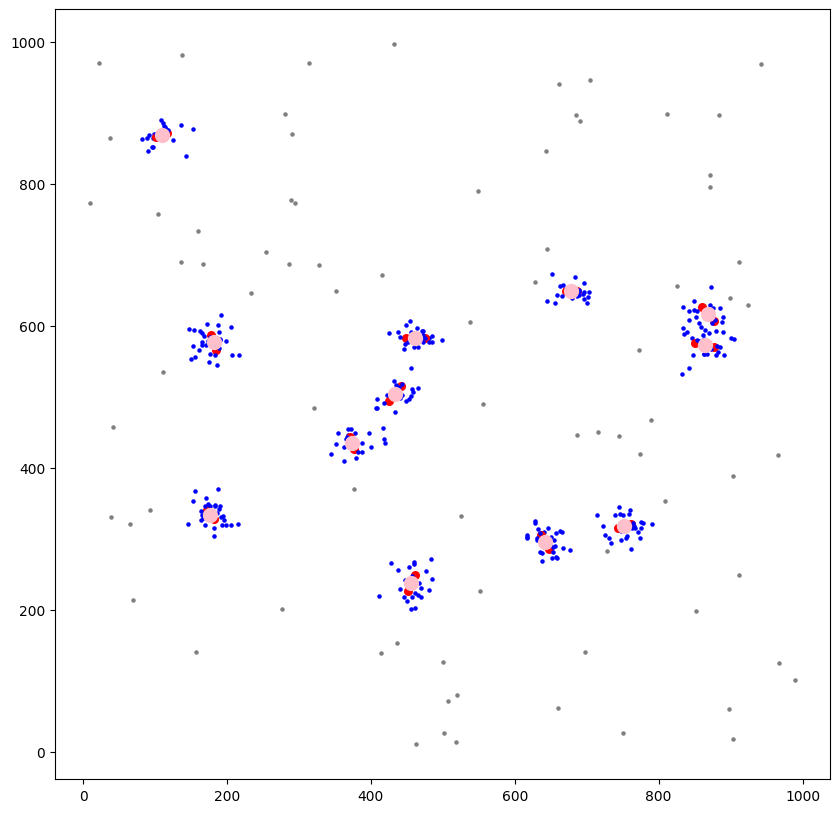

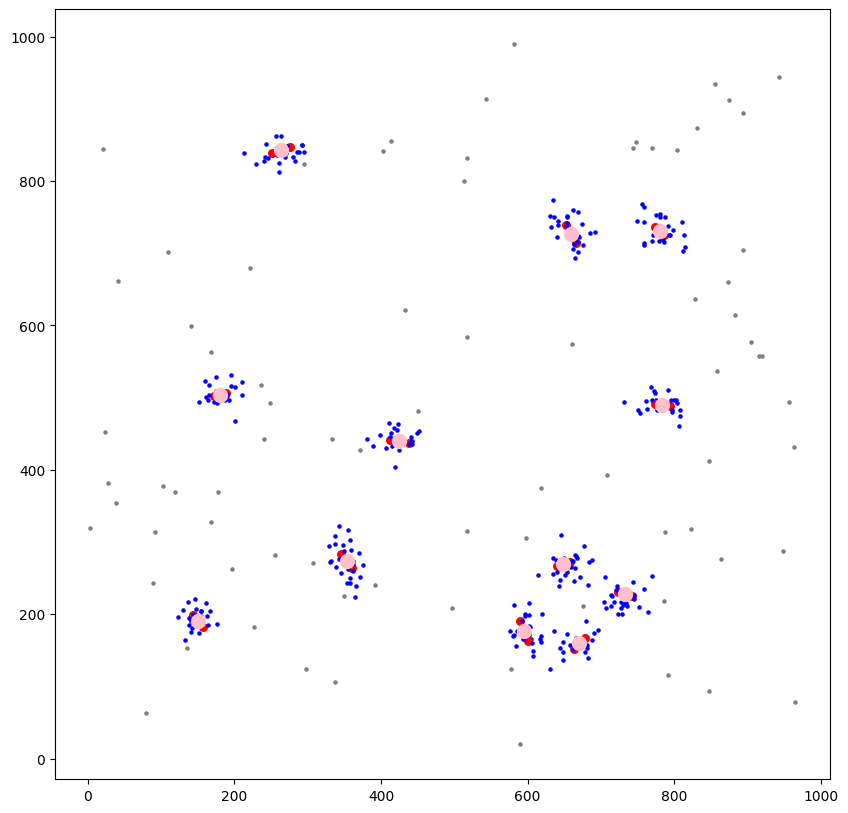

In [ ]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

n_sims=50
disp = True

def generate_chain_cluster(start, n_proteins, link_min, link_max, overlap_min, max_tries=1000):
    proteins = [np.array(start, dtype=float)]

    for _ in range(1, n_proteins):
        placed = False

        for _ in range(max_tries):
            angle = np.random.uniform(0, 2 * np.pi)
            step = np.random.uniform(link_min, link_max)
            candidate = proteins[-1] + step * np.array([np.cos(angle), np.sin(angle)])

            if all(np.linalg.norm(candidate - p) >= overlap_min for p in proteins):
                proteins.append(candidate)
                placed = True
                break

        if not placed:
            break

    proteins = np.array(proteins)
    center = np.mean(proteins, axis=0)   # centroid of all proteins

    return proteins, center


def generate_noise_points(n_noise, H, protein_positions, min_dist, max_tries=100000):
    noise_points = []
    tries = 0

    while len(noise_points) < n_noise and tries < max_tries:
        candidate = np.random.uniform(0, H, size=2).astype(float)

        if all(np.linalg.norm(candidate - p) >= min_dist for p in protein_positions):
            noise_points.append(candidate)

        tries += 1

    if len(noise_points) < n_noise:
        raise ValueError("Could not place all noise points with the required separation.")

    return np.array(noise_points)

H = 2000
W = H
lim = 100

number_of_clusters = 20
# mean_number_of_proteins = 4
# stddev_number_of_proteins = 0
min_number_of_proteins = 5
max_number_of_proteins = 5
mean_number_of_proteins = (min_number_of_proteins + max_number_of_proteins) / 2
# stdev_cluster_radius = 50
link_min = 10      # minimum distance to previous protein
link_max = 20      # maximum distance to previous protein
overlap_min = link_min 
p_geo = 1/2 # 1 means that the mean number of localizations per protein is 1/p_geo
stdev_loc_prec = 15
min_locs_per_protein = 4 # minimum number of localizations per protein
noise_level = 1.0 * number_of_clusters * mean_number_of_proteins * ((1/p_geo) + min_locs_per_protein) # noise level as a function of the number of clusters, proteins and localizations

print(f'Noise: {noise_level}')

output_folder = "csv_generats"
os.makedirs(output_folder, exist_ok=True)

for run in range(n_sims):
    seed_coord = np.random.uniform(lim, H-lim, size=(number_of_clusters, 2))
    cluster_coord = np.zeros((number_of_clusters, 2))
    # noise_coord = np.random.uniform(0, H, size=(int(noise_level), 2))

    index_protein = 0
    index_cluster = 0

    data= []
    protein_positions_all=[]

    if disp:
        fig = plt.figure(figsize=(10, 10))


    for i in range(number_of_clusters):
        index_cluster = index_cluster + 1
        number_of_proteins = np.random.randint(min_number_of_proteins, max_number_of_proteins + 1)
        # number_of_proteins=np.random.normal(mean_number_of_proteins, stddev_number_of_proteins)
        # number_of_proteins = number_of_proteins if number_of_proteins > 0 else 1  

        protein_coord, cc  = generate_chain_cluster(
                                                seed_coord[i], 
                                                number_of_proteins, 
                                                link_min, 
                                                link_max, 
                                                overlap_min
                                                )
        
    
        cluster_coord[i, :]= cc

        for x,y in protein_coord:
            protein_positions_all.append([x, y])

            index_protein = index_protein + 1

            if disp:
                plt.scatter(x, y, color='red', s=30)

            number_of_locs = np.random.geometric(p=p_geo) + min_locs_per_protein # add an offset to have at least min_locs_per_protein + 1 localizations per protein
            for k in range(number_of_locs):
                x_loc = x + np.random.normal(0, stdev_loc_prec)
                y_loc = y + np.random.normal(0, stdev_loc_prec)

                data.append([x_loc, y_loc, index_cluster])

                if disp:
                    plt.scatter(x_loc, y_loc, color='blue', s=5)

    # noise_coord = np.random.uniform(0, H, size=(int(noise_level), 2))

    noise_coord = generate_noise_points(
        n_noise=int(noise_level),
        H=H,
        protein_positions=protein_positions_all,
        min_dist=2*stdev_loc_prec,
    )

    if disp:
        plt.scatter(cluster_coord[:, 0], cluster_coord[:, 1], color='pink', s=100, label='Cluster Centers')
        plt.scatter(noise_coord[:, 0], noise_coord[:, 1], color='gray', s=5, label='Noise')


    for i in range(len(noise_coord)):
        x_noise = noise_coord[i, 0]
        y_noise = noise_coord[i, 1]
        data.append([x_noise, y_noise, 0])
    
    df = pd.DataFrame(data, columns=["x", "y", "index"])
    filename = f"simulated_clusters_CM_{run+1}.csv"
    output_path = os.path.join(output_folder, filename)
    df.to_csv(output_path, index=False)

    print(f"CSV guardado en: {output_path}")